QUANTIZATION REPRESENTATION EXPERIMENT - GRID SEARCH
R values to test: [0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9995, 0.9999]
Number of R values: 8
Loading model: arnir0/TinyLLM
Error loading with AutoModel: arnir0/TinyLLM is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`
Trying alternative loading method...
Error: arnir0/TinyLLM is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`
Creating test model for demonstration...
Extracted 4 weight tensors
Example tensor '0.weight': shape=torch.Size([256, 128]), dtype=torch.float32, min=-0.0884, max=0.0884

/tmp/ipykernel_969/483842663.py:370: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=[f'r={r}' for r in r_unique])


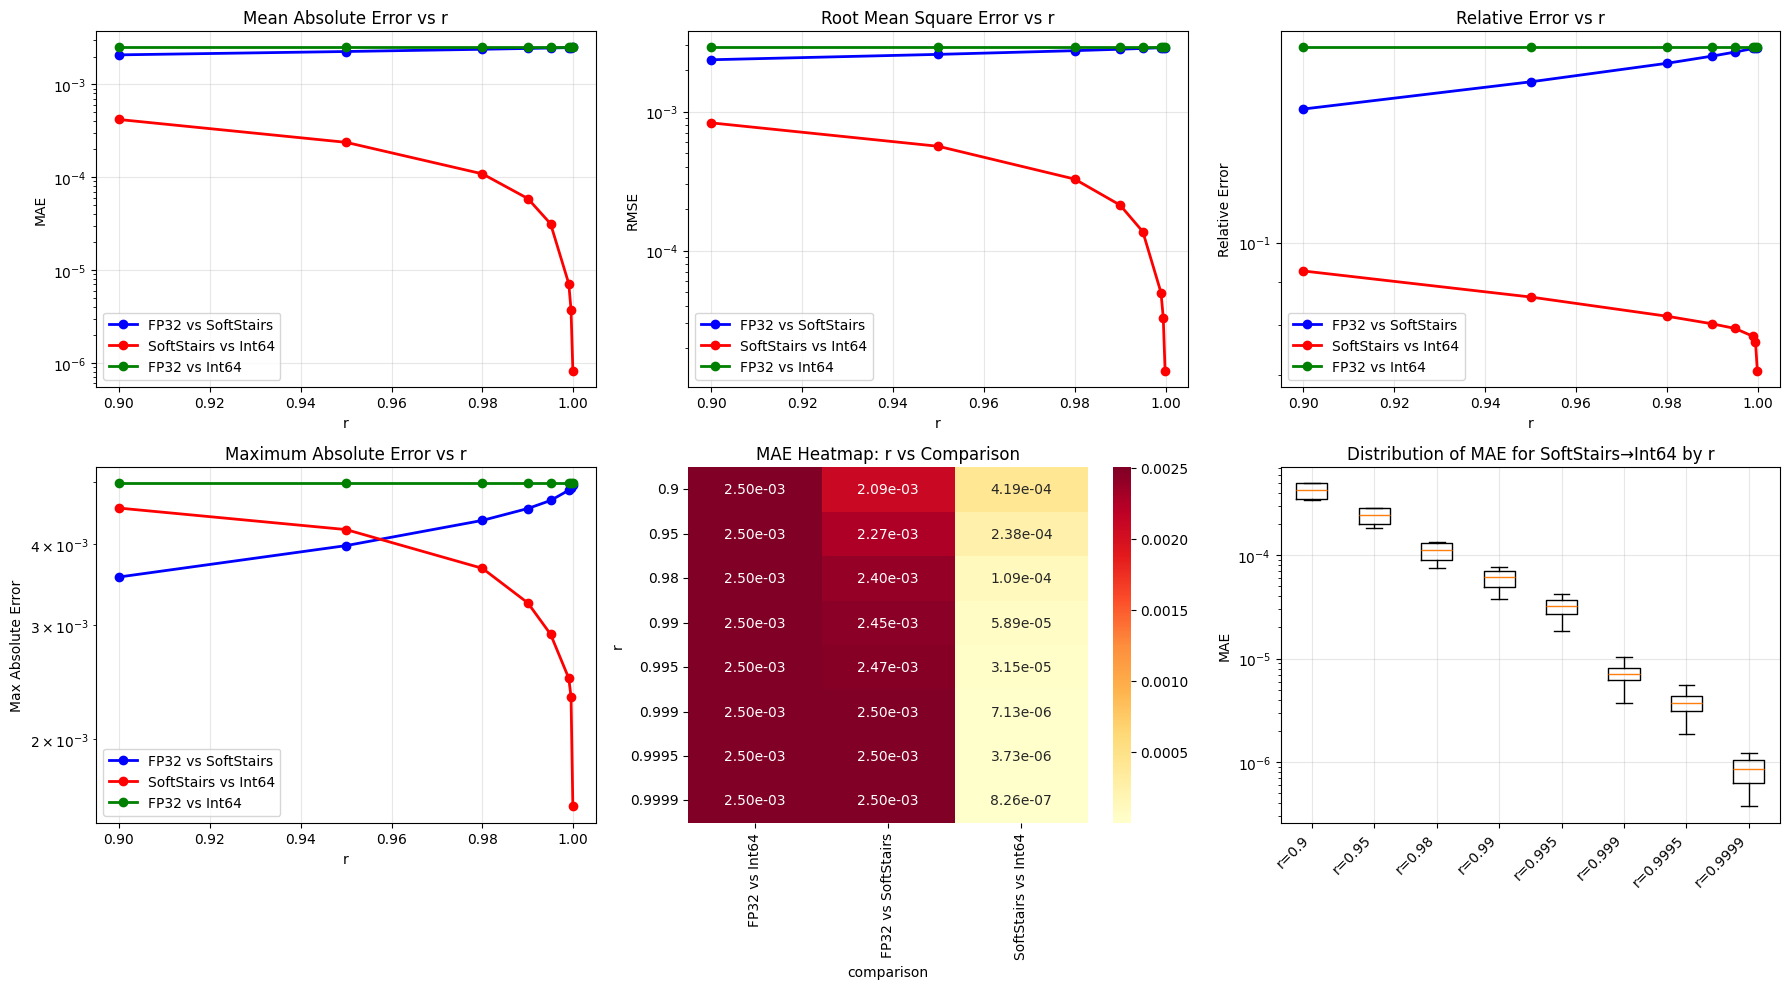

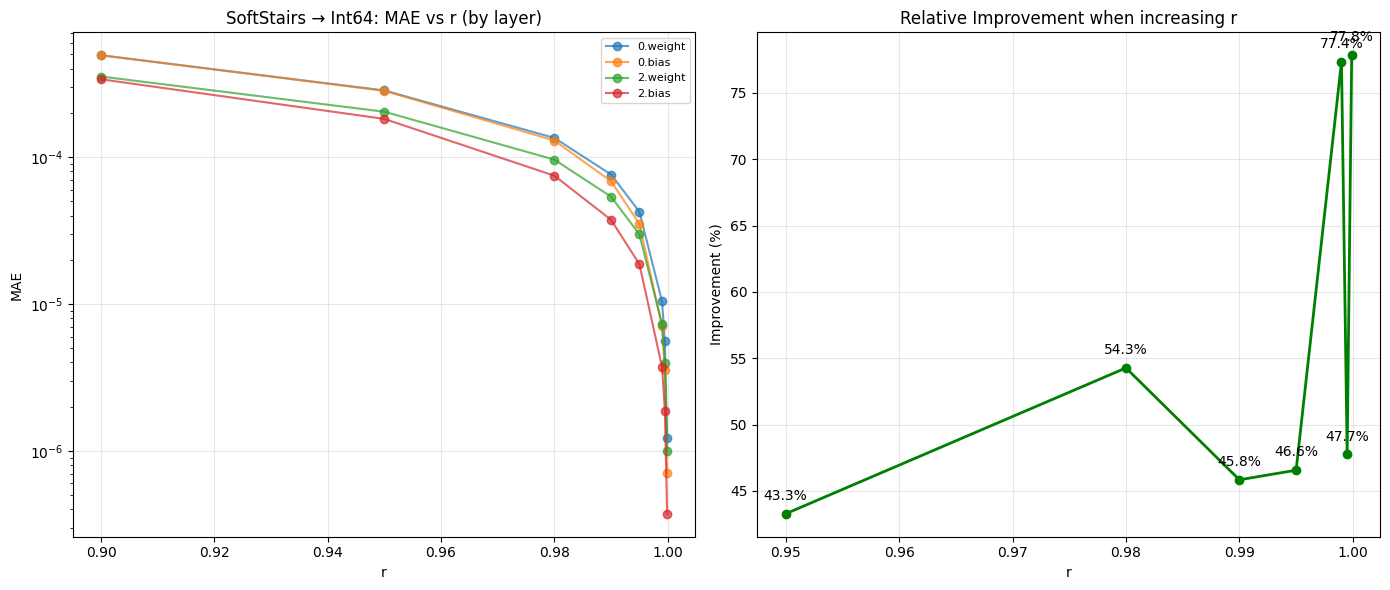


EXPERIMENT COMPLETED


In [4]:
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
from transformers import AutoModel, AutoConfig
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product
import seaborn as sns


# ============================================================
# 1. Определение SoftStairs функции
# ============================================================

def soft_stairs(x, r=0.99):
    """
    Аппроксимация round(x), то есть примерно floor(x + 0.5).
    
    L_r(x) = x + 1/pi * atan2(
        -r sin(2 pi x),
         1 + r cos(2 pi x)
    )
    """
    return x + (1.0 / math.pi) * torch.atan2(
        -r * torch.sin(2.0 * math.pi * x),
        1.0 + r * torch.cos(2.0 * math.pi * x)
    )


def soft_stairs_quantize(tensor, r=0.999, scale=None):
    """
    Применяет SoftStairs к тензору с масштабированием.
    """
    if scale is None:
        min_val = tensor.min()
        max_val = tensor.max()
        scale = (max_val - min_val) / 15.0
        if scale == 0:
            scale = 1.0
    
    scaled = tensor / scale
    soft_scaled = soft_stairs(scaled, r=r)
    quantized = soft_scaled * scale
    
    return quantized, scale


def soft_stairs_to_int64(tensor, r=0.999, scale=None):
    """
    Применяет SoftStairs и преобразует в int64.
    """
    if scale is None:
        min_val = tensor.min()
        max_val = tensor.max()
        scale = (max_val - min_val) / 15.0
        if scale == 0:
            scale = 1.0
    
    scaled = tensor / scale
    soft_scaled = soft_stairs(scaled, r=r)
    int64_tensor = torch.round(soft_scaled).to(torch.int64)
    
    return int64_tensor, scale


def int64_to_float(int64_tensor, scale):
    """Преобразует int64 тензор обратно в float."""
    return int64_tensor.float() * scale


# ============================================================
# 2. Загрузка модели и извлечение весов
# ============================================================

def load_model_weights(model_name="arnir0/TinyLLM"):
    """Загружает модель и возвращает словарь весов."""
    print(f"Loading model: {model_name}")
    
    try:
        config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(
            model_name, 
            config=config, 
            trust_remote_code=True,
            torch_dtype=torch.float32
        )
    except Exception as e:
        print(f"Error loading with AutoModel: {e}")
        print("Trying alternative loading method...")
        try:
            from transformers import AutoModelForCausalLM
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                trust_remote_code=True,
                torch_dtype=torch.float32
            )
        except Exception as e2:
            print(f"Error: {e2}")
            print("Creating test model for demonstration...")
            model = nn.Sequential(
                nn.Linear(128, 256),
                nn.ReLU(),
                nn.Linear(256, 128)
            )
    
    weights_dict = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights_dict[name] = param.data.clone()
    
    print(f"Extracted {len(weights_dict)} weight tensors")
    
    first_name = list(weights_dict.keys())[0]
    print(f"Example tensor '{first_name}': shape={weights_dict[first_name].shape}, "
          f"dtype={weights_dict[first_name].dtype}, "
          f"min={weights_dict[first_name].min().item():.4f}, "
          f"max={weights_dict[first_name].max().item():.4f}")
    
    return weights_dict


# ============================================================
# 3. Сохранение и загрузка
# ============================================================

def save_weights_dict(weights_dict, path="weights_dict.pt"):
    torch.save(weights_dict, path)
    print(f"Weights saved to {path}")
    return path


def load_weights_dict(path="weights_dict.pt"):
    weights_dict = torch.load(path)
    print(f"Weights loaded from {path}")
    return weights_dict


# ============================================================
# 4. Метрики ошибок
# ============================================================

def compute_error_metrics(tensor1, tensor2, name="tensor"):
    """Вычисляет метрики ошибки между двумя тензорами."""
    diff = tensor1.float() - tensor2.float()
    
    mae = diff.abs().mean().item()
    mse = (diff ** 2).mean().item()
    rmse = np.sqrt(mse)
    max_abs = diff.abs().max().item()
    rel_error = (diff.abs() / (tensor1.abs() + 1e-8)).mean().item()
    
    error_percentiles = {
        '1%': np.percentile(diff.abs().cpu().numpy(), 1),
        '5%': np.percentile(diff.abs().cpu().numpy(), 5),
        '25%': np.percentile(diff.abs().cpu().numpy(), 25),
        '50%': np.percentile(diff.abs().cpu().numpy(), 50),
        '75%': np.percentile(diff.abs().cpu().numpy(), 75),
        '95%': np.percentile(diff.abs().cpu().numpy(), 95),
        '99%': np.percentile(diff.abs().cpu().numpy(), 99),
    }
    
    return {
        'name': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MaxAbs': max_abs,
        'RelError': rel_error,
        'error_percentiles': error_percentiles
    }


def compare_representations(original_tensor, soft_stairs_tensor, int64_tensor, scale):
    """Сравнивает три представления тензора."""
    int64_float = int64_tensor.float() * scale
    
    results = []
    results.append(compute_error_metrics(original_tensor, soft_stairs_tensor, "FP32 vs SoftStairs"))
    results.append(compute_error_metrics(soft_stairs_tensor, int64_float, "SoftStairs vs Int64"))
    results.append(compute_error_metrics(original_tensor, int64_float, "FP32 vs Int64"))
    
    return results


# ============================================================
# 5. Полный эксперимент с сеткой r значений
# ============================================================

def run_quantization_experiment_grid(
    model_name="arnir0/TinyLLM",
    r_values=[0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9995, 0.9999],
    save_load=True,
    save_path="weights_dict.pt"
):
    """
    Запускает эксперимент с сеткой значений r.
    r теперь является отдельным измерением в результатах.
    """
    print("=" * 80)
    print("QUANTIZATION REPRESENTATION EXPERIMENT - GRID SEARCH")
    print("=" * 80)
    print(f"R values to test: {r_values}")
    print(f"Number of R values: {len(r_values)}")
    
    # Загружаем модель и веса
    weights_dict = load_model_weights(model_name)
    
    if save_load:
        save_weights_dict(weights_dict, save_path)
        weights_dict = load_weights_dict(save_path)
    
    # Структура для хранения результатов: [layer][r][comparison]
    results_grid = defaultdict(lambda: defaultdict(dict))
    
    # Таблица для всех результатов
    all_results = []
    
    for r in r_values:
        print(f"\n{'='*60}")
        print(f"Testing r = {r}")
        print(f"{'='*60}")
        
        for name, tensor in weights_dict.items():
            print(f"  Processing layer: {name[:30]}... (shape: {tuple(tensor.shape)})")
            
            # Применяем SoftStairs
            soft_tensor, scale = soft_stairs_quantize(tensor, r=r)
            
            # Применяем SoftStairs + Int64
            int64_tensor, int_scale = soft_stairs_to_int64(tensor, r=r)
            
            # Сравниваем представления
            comparisons = compare_representations(tensor, soft_tensor, int64_tensor, int_scale)
            
            # Сохраняем результаты
            for comp in comparisons:
                result_entry = {
                    'r': r,
                    'layer_name': name,
                    'layer_type': 'weight' if 'weight' in name else 'bias',
                    'comparison': comp['name'],
                    'MAE': comp['MAE'],
                    'MSE': comp['MSE'],
                    'RMSE': comp['RMSE'],
                    'MaxAbs': comp['MaxAbs'],
                    'RelError': comp['RelError'],
                    'scale': scale
                }
                
                # Добавляем процентили
                for percentile, value in comp['error_percentiles'].items():
                    result_entry[f'error_percentile_{percentile}'] = value
                
                all_results.append(result_entry)
                
                # Сохраняем в grid структуру
                results_grid[name][r][comp['name']] = comp
    
    # Создаём DataFrame
    df_results = pd.DataFrame(all_results)
    
    return df_results, results_grid, weights_dict


# ============================================================
# 6. Анализ и визуализация с r как измерением
# ============================================================

def analyze_r_dependency(df_results):
    """
    Анализирует зависимость ошибок от r.
    """
    print("\n" + "=" * 80)
    print("ANALYSIS: DEPENDENCY ON R")
    print("=" * 80)
    
    # Группируем по r и comparison
    grouped = df_results.groupby(['r', 'comparison']).agg({
        'MAE': ['mean', 'std', 'min', 'max'],
        'RMSE': ['mean', 'std'],
        'RelError': ['mean', 'std'],
        'MaxAbs': ['mean', 'max']
    }).round(6)
    
    print("\nAggregated statistics by r:")
    print(grouped)
    
    return grouped


def plot_r_dependency(df_results):
    """
    Строит графики зависимости ошибок от r.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    comparisons = df_results['comparison'].unique()
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # 1. MAE vs r
    ax = axes[0, 0]
    for i, comp in enumerate(comparisons):
        subset = df_results[df_results['comparison'] == comp]
        r_sorted = subset.groupby('r')['MAE'].mean().sort_index()
        ax.plot(r_sorted.index, r_sorted.values, marker='o', label=comp, color=colors[i % len(colors)], linewidth=2)
    ax.set_xlabel('r')
    ax.set_ylabel('MAE')
    ax.set_title('Mean Absolute Error vs r')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 2. RMSE vs r
    ax = axes[0, 1]
    for i, comp in enumerate(comparisons):
        subset = df_results[df_results['comparison'] == comp]
        r_sorted = subset.groupby('r')['RMSE'].mean().sort_index()
        ax.plot(r_sorted.index, r_sorted.values, marker='o', label=comp, color=colors[i % len(colors)], linewidth=2)
    ax.set_xlabel('r')
    ax.set_ylabel('RMSE')
    ax.set_title('Root Mean Square Error vs r')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 3. Relative Error vs r
    ax = axes[0, 2]
    for i, comp in enumerate(comparisons):
        subset = df_results[df_results['comparison'] == comp]
        r_sorted = subset.groupby('r')['RelError'].mean().sort_index()
        ax.plot(r_sorted.index, r_sorted.values, marker='o', label=comp, color=colors[i % len(colors)], linewidth=2)
    ax.set_xlabel('r')
    ax.set_ylabel('Relative Error')
    ax.set_title('Relative Error vs r')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 4. MaxAbs Error vs r
    ax = axes[1, 0]
    for i, comp in enumerate(comparisons):
        subset = df_results[df_results['comparison'] == comp]
        r_sorted = subset.groupby('r')['MaxAbs'].mean().sort_index()
        ax.plot(r_sorted.index, r_sorted.values, marker='o', label=comp, color=colors[i % len(colors)], linewidth=2)
    ax.set_xlabel('r')
    ax.set_ylabel('Max Absolute Error')
    ax.set_title('Maximum Absolute Error vs r')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 5. Heatmap: MAE по r и comparison
    ax = axes[1, 1]
    pivot_mae = df_results.pivot_table(index='r', columns='comparison', values='MAE', aggfunc='mean')
    sns.heatmap(pivot_mae, annot=True, fmt='.2e', cmap='YlOrRd', ax=ax)
    ax.set_title('MAE Heatmap: r vs Comparison')
    
    # 6. Boxplot распределения MAE по r (исправленная версия)
    ax = axes[1, 2]
    # Берём только SoftStairs vs Int64 для наглядности
    subset_soft_int64 = df_results[df_results['comparison'] == 'SoftStairs vs Int64']
    
    # Группируем по r
    r_unique = sorted(subset_soft_int64['r'].unique())
    box_data = [subset_soft_int64[subset_soft_int64['r'] == r]['MAE'].values for r in r_unique]
    
    # Создаём boxplot (без параметра rot)
    bp = ax.boxplot(box_data, labels=[f'r={r}' for r in r_unique])
    
    # Поворачиваем подписи отдельно
    ax.set_xticklabels([f'r={r}' for r in r_unique], rotation=45, ha='right')
    ax.set_ylabel('MAE')
    ax.set_title('Distribution of MAE for SoftStairs→Int64 by r')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('r_dependency_analysis.png', dpi=200)
    plt.show()


def plot_r_vs_accuracy_tradeoff(df_results):
    """
    Анализ trade-off между точностью и значением r.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Берём только SoftStairs vs Int64
    subset = df_results[df_results['comparison'] == 'SoftStairs vs Int64']
    
    # 1. MAE vs r с разными слоями
    ax = axes[0]
    for layer in subset['layer_name'].unique():
        layer_subset = subset[subset['layer_name'] == layer]
        r_sorted = layer_subset.groupby('r')['MAE'].mean().sort_index()
        ax.plot(r_sorted.index, r_sorted.values, marker='o', label=layer[:30], alpha=0.7)
    ax.set_xlabel('r')
    ax.set_ylabel('MAE')
    ax.set_title('SoftStairs → Int64: MAE vs r (by layer)')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    
    # 2. Improvement rate (производная)
    ax = axes[1]
    r_values = sorted(subset['r'].unique())
    mean_mae = [subset[subset['r'] == r]['MAE'].mean() for r in r_values]
    
    # Вычисляем скорость улучшения
    improvements = []
    for i in range(1, len(mean_mae)):
        if mean_mae[i-1] > 0:
            improvement = (mean_mae[i-1] - mean_mae[i]) / mean_mae[i-1] * 100
        else:
            improvement = 0
        improvements.append(improvement)
    
    ax.plot(r_values[1:], improvements, marker='o', linewidth=2, color='green')
    ax.set_xlabel('r')
    ax.set_ylabel('Improvement (%)')
    ax.set_title('Relative Improvement when increasing r')
    ax.grid(True, alpha=0.3)
    
    # Добавляем аннотации
    for i, (r, imp) in enumerate(zip(r_values[1:], improvements)):
        ax.annotate(f'{imp:.1f}%', (r, imp), textcoords="offset points", xytext=(0, 10), ha='center')
    
    plt.tight_layout()
    plt.savefig('r_accuracy_tradeoff.png', dpi=200)
    plt.show()


def print_r_summary_table(df_results):
    """
    Печатает сводную таблицу зависимости от r.
    """
    print("\n" + "=" * 100)
    print("R-DEPENDENCY SUMMARY TABLE")
    print("=" * 100)
    
    # Сводка по r для SoftStairs vs Int64
    subset = df_results[df_results['comparison'] == 'SoftStairs vs Int64']
    
    summary_data = []
    for r in sorted(subset['r'].unique()):
        r_subset = subset[subset['r'] == r]
        summary_data.append({
            'r': r,
            'Mean_MAE': r_subset['MAE'].mean(),
            'Std_MAE': r_subset['MAE'].std(),
            'Min_MAE': r_subset['MAE'].min(),
            'Max_MAE': r_subset['MAE'].max(),
            'Mean_RelError': r_subset['RelError'].mean(),
            'Mean_RMSE': r_subset['RMSE'].mean()
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Находим оптимальное r
    optimal_r = summary_df.loc[summary_df['Mean_MAE'].idxmin(), 'r']
    print(f"\n📌 Optimal r (min MAE): {optimal_r}")
    
    # Вычисляем пороги
    thresholds = [1e-4, 1e-5, 1e-6]
    print("\n📊 Required r for target accuracy:")
    for thresh in thresholds:
        required_r = summary_df[summary_df['Mean_MAE'] <= thresh]['r'].min() if any(summary_df['Mean_MAE'] <= thresh) else None
        if required_r:
            print(f"  MAE ≤ {thresh:.0e} requires r ≥ {required_r}")
        else:
            print(f"  MAE ≤ {thresh:.0e} not achieved in tested range")


# ============================================================
# 7. Основной запуск
# ============================================================

if __name__ == "__main__":
    # Параметры эксперимента с сеткой r
    R_VALUES = [0.9, 0.95, 0.98, 0.99, 0.995, 0.999, 0.9995, 0.9999]
    
    MODEL_NAME = "arnir0/TinyLLM"  # Или используйте свою модель
    SAVE_LOAD = True
    SAVE_PATH = "tinyllm_weights.pt"
    
    # Запуск эксперимента с сеткой
    df_results, results_grid, weights_dict = run_quantization_experiment_grid(
        model_name=MODEL_NAME,
        r_values=R_VALUES,
        save_load=SAVE_LOAD,
        save_path=SAVE_PATH
    )
    
    # Сохраняем результаты
    df_results.to_csv("quantization_experiment_grid.csv", index=False)
    print(f"\n✅ Results saved to quantization_experiment_grid.csv")
    
    # Анализ зависимости от r
    analyze_r_dependency(df_results)
    print_r_summary_table(df_results)
    
    # Визуализация
    plot_r_dependency(df_results)
    plot_r_vs_accuracy_tradeoff(df_results)
    
    print("\n" + "=" * 80)
    print("EXPERIMENT COMPLETED")
    print("=" * 80)

/home/user/projects/FedCore/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



QUANTIZATION EXPERIMENT ON MNIST - 20.0% OF DATA (ALL METHODS INT32)
Model: microsoft/resnet-18 (pretrained on ImageNet, fine-tuned on MNIST)
Input: 224x224 RGB (grayscale duplicated to 3 channels)
Methods: none, torch_quant (INT32, STE with round), soft_stairs, soft_stairs_int
Using 20.0% of training and test data
QUANTIZATION EXPERIMENT ON MNIST (INT32)
Device: cuda, Model: microsoft/resnet-18
Quantization bits: 32
Methods: ['none', 'torch_quant', 'soft_stairs', 'soft_stairs_int']
Data fraction: 20.0% of full dataset
MNIST loaded (fraction=0.2): train=12000, test=2000
Input shape: (3, 224, 224), output classes: 10

CREATING BASE MODEL WITH FIXED INITIALIZATION (pretrained weights)


Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([10, 512]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Base model created with seed=42
Sample weight (first param): -0.01041935

Experiment: none, r=N/A, bits=32
  Epoch 1/50: Loss=0.1353, Acc=0.9610, F1=0.9609, LR=0.000999
  Epoch 2/50: Loss=0.0590, Acc=0.9580, F1=0.9589, LR=0.000996
  Epoch 3/50: Loss=0.0339, Acc=0.9780, F1=0.9780, LR=0.000991
  Epoch 4/50: Loss=0.0255, Acc=0.9710, F1=0.9713, LR=0.000984
  Epoch 5/50: Loss=0.0274, Acc=0.9895, F1=0.9895, LR=0.000976
  Epoch 6/50: Loss=0.0281, Acc=0.9890, F1=0.9890, LR=0.000965
  Epoch 7/50: Loss=0.0123, Acc=0.9880, F1=0.9880, LR=0.000952
  Epoch 8/50: Loss=0.0104, Acc=0.9695, F1=0.9696, LR=0.000938
  Epoch 9/50: Loss=0.0136, Acc=0.9875, F1=0.9875, LR=0.000922
  Epoch 10/50: Loss=0.0145, Acc=0.9820, F1=0.9820, LR=0.000905
  Epoch 11/50: Loss=0.0114, Acc=0.9935, F1=0.9935, LR=0.000885
  Epoch 12/50: Loss=0.0046, Acc=0.9920, F1=0.9920, LR=0.000865
  Epoch 13/50: Loss=0.0073, Acc=0.9840, F1=0.9840, LR=0.000842
  Epoch 14/50: Loss=0.0205, Acc=0.9870, F1=0.9870, LR=0.000819
  Epoch 15/50: Loss=

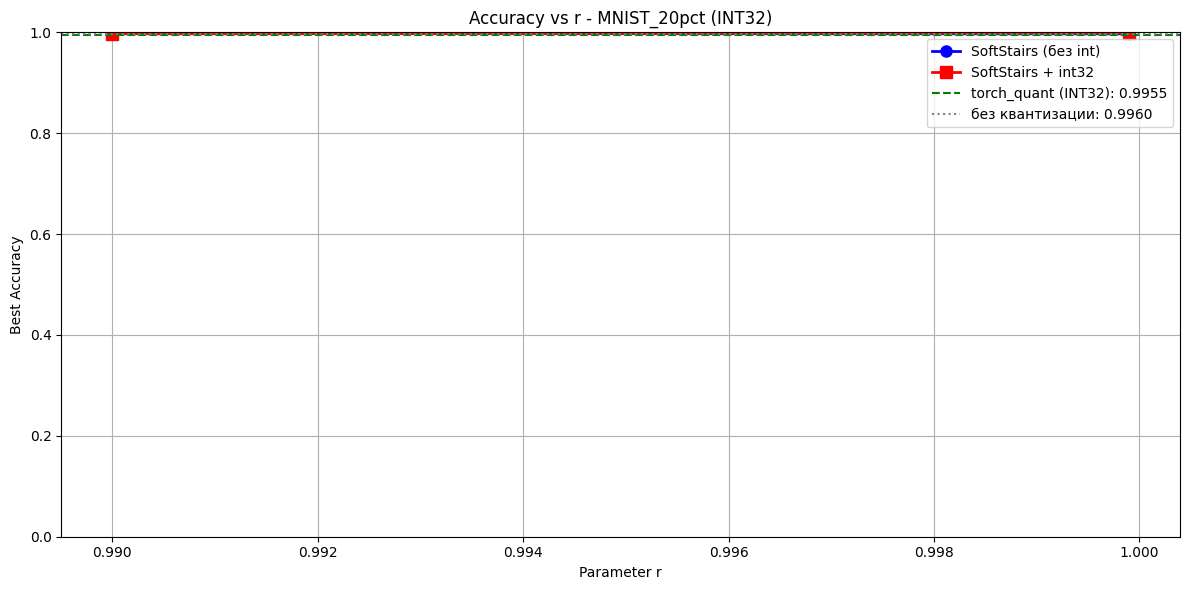

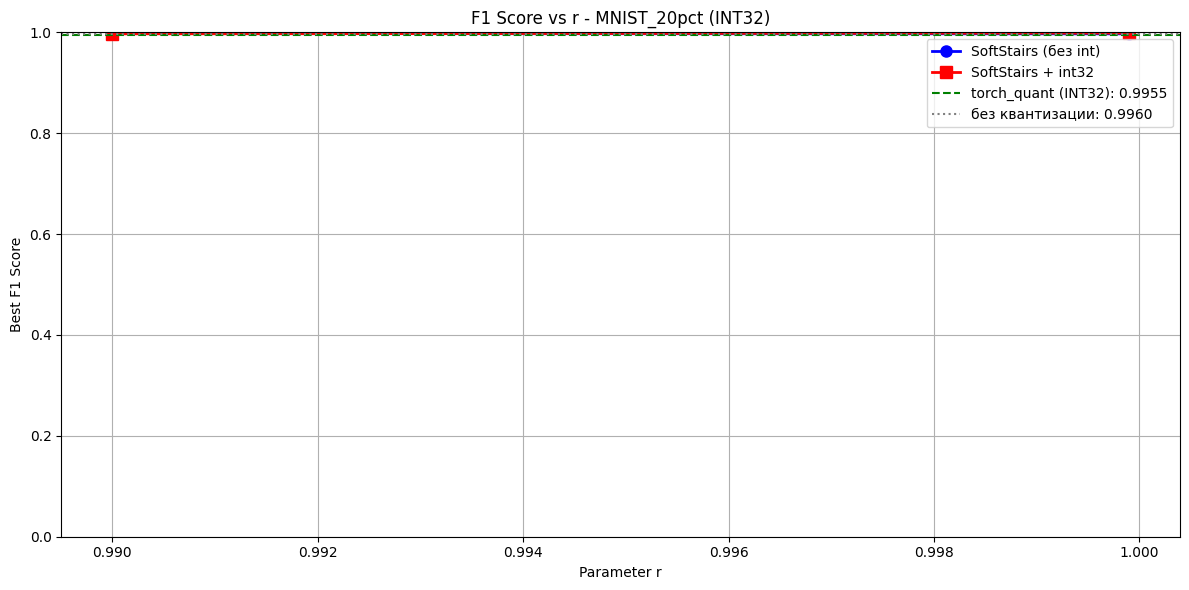

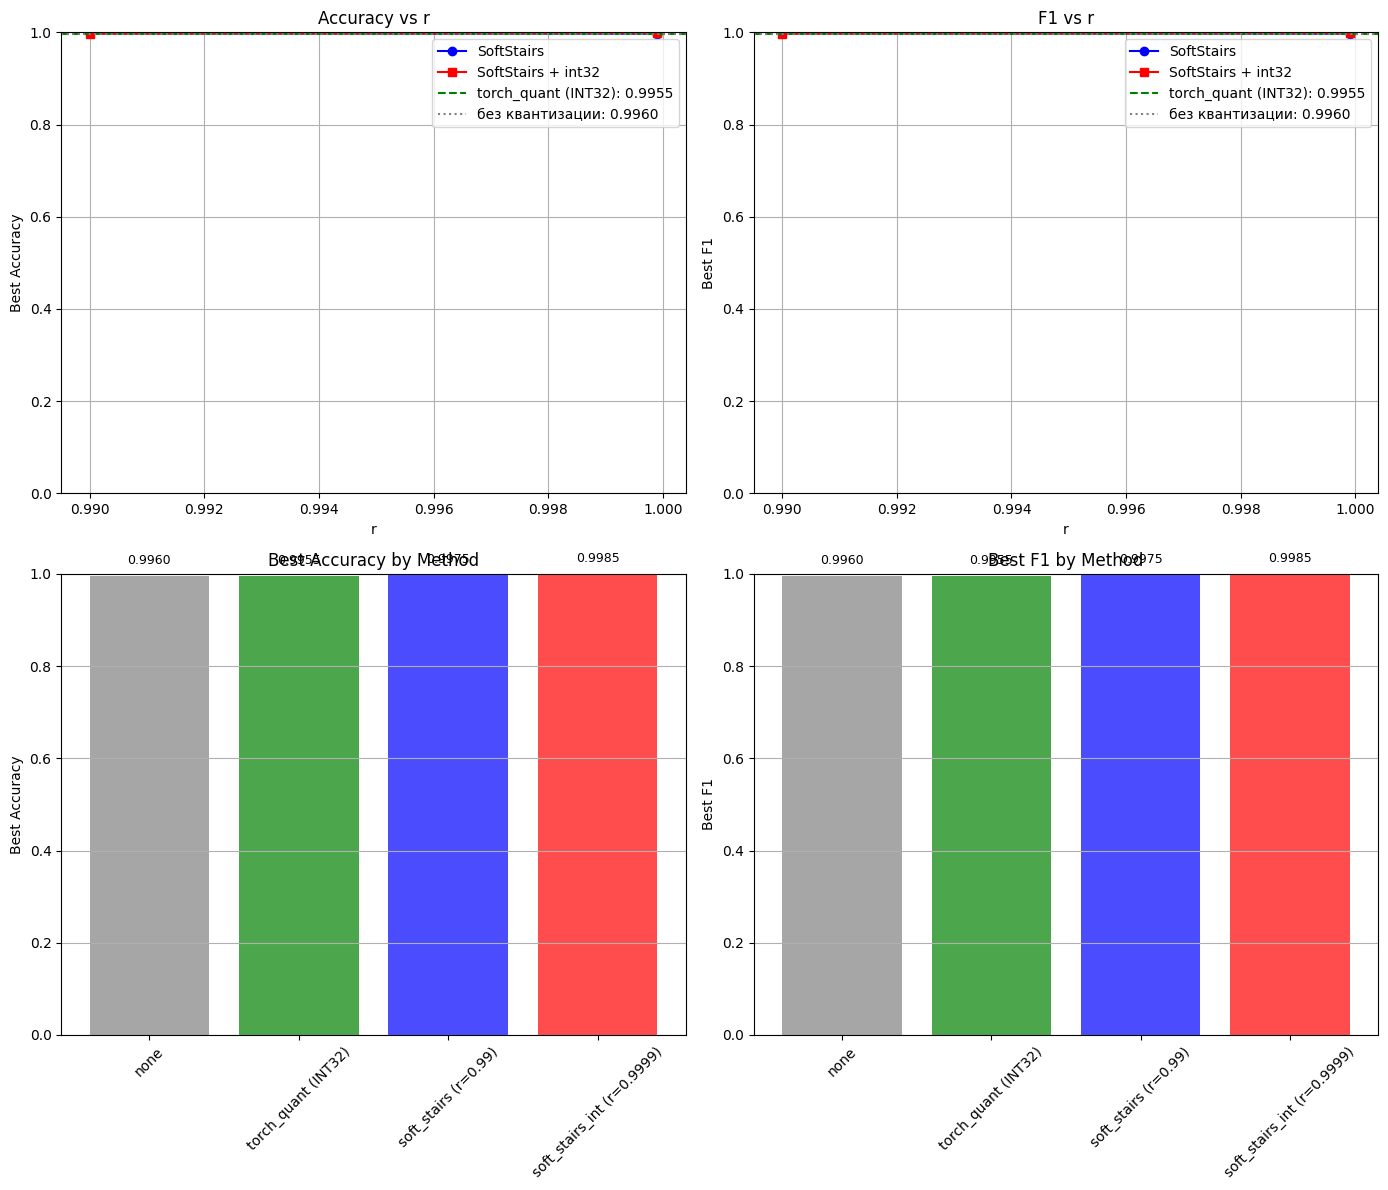


✅ All plots saved successfully!


In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import sys
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms, datasets
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from contextlib import contextmanager
import time
import copy
import psutil
import gc
import os
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForImageClassification, AutoConfig
import torch.quantization as tq
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. Детерминированные настройки
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True, warn_only=True)

MASTER_SEED = 42
set_seed(MASTER_SEED)

# ============================================================
# 1. Определение SoftStairs
# ============================================================

def soft_stairs(x, r=0.99):
    return x + (1.0 / math.pi) * torch.atan2(
        -r * torch.sin(2.0 * math.pi * x),
        1.0 + r * torch.cos(2.0 * math.pi * x)
    )# - ((1 - r) / (r + 1)) * x

def soft_stairs_derivative(x, r=0.99):
    return (1.0 - r * r) / (
        1.0 + 2.0 * r * torch.cos(2.0 * math.pi * x) + r * r
    ) #  - (1 - r) / (r + 1)

# ============================================================
# 2a. Вычисление параметров квантизации (для torch quantization) - ТЕПЕРЬ INT32
# ============================================================

def compute_scale_and_zero_point_torch(tensor, n_bits=32):
    """Вычисление scale и zero_point для torch quantization (INT32)"""
    q_min = -2**(n_bits-1)
    q_max = 2**(n_bits-1) - 1
    min_val = tensor.min()
    max_val = tensor.max()
    eps = 1e-6
    
    min_val = min_val - eps
    max_val = max_val + eps
    
    scale = (max_val - min_val) / (q_max - q_min)
    if scale == 0 or torch.isinf(scale):
        scale = 1.0
    
    zero_point = q_min - min_val / scale
    zero_point = torch.round(zero_point)
    zero_point = torch.clamp(zero_point, q_min, q_max)
    
    return scale, zero_point

def quantize_torch_tensor(tensor, scale, zero_point, q_min, q_max):
    """Квантизация тензора с помощью torch.round"""
    quantized = torch.round(tensor / scale + zero_point)
    quantized = torch.clamp(quantized, q_min, q_max)
    return quantized

def dequantize_torch_tensor(quantized, scale, zero_point):
    """Деквантизация тензора"""
    return scale * (quantized - zero_point)

# ============================================================
# 2b. Вычисление параметров квантизации (для SoftStairs) – БЕЗ round
# ============================================================

def compute_scale_and_zero_point_soft(tensor, n_bits=32):
    q_min = -2**(n_bits-1)
    q_max = 2**(n_bits-1) - 1
    min_val = tensor.min()
    max_val = tensor.max()
    eps = 1e-6
    min_val = min_val - eps
    max_val = max_val + eps
    scale = (q_max - q_min) / (max_val - min_val)
    if scale == 0 or torch.isinf(scale):
        scale = 1.0
    zero_point = q_min - min_val * scale
    return scale, zero_point, q_min, q_max

# ============================================================
# 3. Autograd функции для квантизации
# ============================================================

class TorchQuantizeSTE(torch.autograd.Function):
    """Использует стандартный round из PyTorch (INT32)"""
    @staticmethod
    def forward(ctx, weight, n_bits=32):
        scale, zero_point = compute_scale_and_zero_point_torch(weight, n_bits)
        q_min = -2**(n_bits-1)
        q_max = 2**(n_bits-1) - 1
        
        ctx.scale = scale
        ctx.zero_point = zero_point
        
        quantized = quantize_torch_tensor(weight, scale, zero_point, q_min, q_max)
        dequantized = dequantize_torch_tensor(quantized, scale, zero_point)
        return dequantized
    
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

class SoftStairsQuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, weight, r, n_bits=32):
        scale, zero_point, q_min, q_max = compute_scale_and_zero_point_soft(weight, n_bits)
        ctx.r = r
        ctx.scale = scale
        ctx.zero_point = zero_point
        scaled = weight * scale + zero_point
        soft_rounded = soft_stairs(scaled, r=r)
        soft_rounded = torch.clamp(soft_rounded, q_min, q_max)
        dequantized = (soft_rounded - zero_point) / scale
        ctx.save_for_backward(scaled)
        return dequantized
    
    @staticmethod
    def backward(ctx, grad_output):
        scaled, = ctx.saved_tensors
        r = ctx.r
        scale = ctx.scale
        derivative = soft_stairs_derivative(scaled, r=r)
        grad_weight = grad_output * derivative * scale
        return grad_weight, None, None

def quantize_torch_ste(weight, n_bits=32):
    """Квантизация с round как в torch.quantization (INT32)"""
    return TorchQuantizeSTE.apply(weight, n_bits)

def quantize_soft_stairs_ste(weight, r=0.99, n_bits=32):
    return SoftStairsQuantizeSTE.apply(weight, r, n_bits)

# ============================================================
# 4. Контекстный менеджер для весов
# ============================================================

class QuantizedContext:
    def __init__(self, model, quantization_type="none", r=0.99, n_bits=32):
        self.model = model
        self.quantization_type = quantization_type
        self.r = r
        self.n_bits = n_bits

    def __enter__(self):
        if self.quantization_type == "none":
            return
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                if self.quantization_type == "torch_quant":
                    param.data = quantize_torch_ste(param.data, self.n_bits)
                elif self.quantization_type == "soft_stairs":
                    param.data = quantize_soft_stairs_ste(param.data, self.r, self.n_bits)
                elif self.quantization_type == "soft_stairs_int":
                    param.data = quantize_soft_stairs_ste(param.data, self.r, self.n_bits)

    def __exit__(self, exc_type, exc_val, exc_tb):
        pass

@contextmanager
def quantized_weights_context(model, quantization_type="none", r=0.99, n_bits=32):
    ctx = QuantizedContext(model, quantization_type, r, n_bits)
    ctx.__enter__()
    try:
        yield
    finally:
        ctx.__exit__(None, None, None)

# ============================================================
# 5. Модель на основе transformers (ResNet-18)
# ============================================================

def create_base_model(num_classes=10, seed=MASTER_SEED):
    set_seed(seed)
    config = AutoConfig.from_pretrained("microsoft/resnet-18")
    config.num_labels = num_classes
    model = AutoModelForImageClassification.from_pretrained(
        "microsoft/resnet-18",
        config=config,
        ignore_mismatched_sizes=True
    )
    return model

def get_model_copy(source_model):
    return copy.deepcopy(source_model)

# ============================================================
# 6. Загрузка датасета MNIST
# ============================================================

def load_mnist_deterministic(batch_size=64, seed=42, use_fraction=1.0):
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    full_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    if use_fraction < 1.0:
        g = torch.Generator()
        g.manual_seed(seed)
        train_indices = torch.randperm(len(full_train), generator=g)[:int(len(full_train) * use_fraction)]
        test_indices = torch.randperm(len(full_test), generator=g)[:int(len(full_test) * use_fraction)]
        
        train_subset = torch.utils.data.Subset(full_train, train_indices.tolist())
        test_subset = torch.utils.data.Subset(full_test, test_indices.tolist())
        
        g_train = torch.Generator()
        g_train.manual_seed(seed)
        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, generator=g_train)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
        
        print(f"MNIST loaded (fraction={use_fraction}): train={len(train_subset)}, test={len(test_subset)}")
    else:
        g = torch.Generator()
        g.manual_seed(seed)
        train_loader = DataLoader(full_train, batch_size=batch_size, shuffle=True, generator=g)
        test_loader = DataLoader(full_test, batch_size=batch_size, shuffle=False)
        print(f"MNIST loaded (full): train={len(full_train)}, test={len(full_test)}")
    
    print(f"Input shape: (3, 224, 224), output classes: 10")
    return train_loader, test_loader, 3*224*224, 10

# ============================================================
# 7. Вычисление метрик
# ============================================================

def compute_model_metrics(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            logits = outputs.logits
            loss = criterion(logits, target)
            total_loss += loss.item()
            pred = logits.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    avg_loss = total_loss / len(test_loader)
    return {'accuracy': accuracy, 'f1_score': f1, 'avg_loss': avg_loss}

# ============================================================
# 8. Обучение одной конфигурации
# ============================================================

def train_single_config(
    quantization_type,
    r,
    train_loader,
    test_loader,
    base_model,
    n_epochs=30,
    learning_rate=0.001,
    weight_decay=1e-5,
    n_bits=32,  # Все методы теперь используют INT32
    profile_memory=True
):
    model = get_model_copy(base_model)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    memory_stats = None
    if profile_memory:
        profiler = MemoryProfiler(device)
        profiler.start()

    epoch_losses = []
    epoch_accuracies = []
    epoch_f1_scores = []
    best_accuracy = 0
    best_epoch = 0

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            with quantized_weights_context(model, quantization_type, r, n_bits):
                optimizer.zero_grad()
                outputs = model(data)
                logits = outputs.logits
                loss = criterion(logits, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(train_loader)
        epoch_losses.append(avg_epoch_loss)

        # Для soft_stairs_int – приведение весов к int32
        if quantization_type == "soft_stairs_int":
            model_int = get_model_copy(model)
            for name, param in model_int.named_parameters():
                if param.requires_grad:
                    scale, zero_point, q_min, q_max = compute_scale_and_zero_point_soft(param.data, 32)
                    scaled = param.data * scale + zero_point
                    int32_values = scaled.to(torch.int32)
                    int32_values = torch.clamp(int32_values, q_min, q_max)
                    param.data = (int32_values.float() - zero_point) / scale
            test_metrics = compute_model_metrics(model_int, test_loader, device)
        else:
            test_metrics = compute_model_metrics(model, test_loader, device)

        epoch_accuracies.append(test_metrics['accuracy'])
        epoch_f1_scores.append(test_metrics['f1_score'])
        scheduler.step()

        if test_metrics['accuracy'] > best_accuracy:
            best_accuracy = test_metrics['accuracy']
            best_epoch = epoch + 1

        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1}/{n_epochs}: Loss={avg_epoch_loss:.4f}, "
              f"Acc={test_metrics['accuracy']:.4f}, "
              f"F1={test_metrics['f1_score']:.4f}, "
              f"LR={current_lr:.6f}")

    if profile_memory:
        memory_stats = profiler.end()
        print(f"\n  Memory Profile:")
        if torch.cuda.is_available():
            print(f"    Peak GPU: {memory_stats['peak_gpu_memory_mb']:.2f} MB")

    print(f"\n  Best Accuracy: {best_accuracy:.4f} (epoch {best_epoch})")

    result = {
        'quantization_type': quantization_type,
        'r': r,
        'n_bits': n_bits,
        'best_accuracy': best_accuracy,
        'best_epoch': best_epoch,
        'best_f1': max(epoch_f1_scores),
        'final_accuracy': epoch_accuracies[-1],
        'final_loss': epoch_losses[-1],
        'final_f1': epoch_f1_scores[-1],
    }
    if memory_stats:
        result['peak_gpu_memory_mb'] = memory_stats['peak_gpu_memory_mb']
    return result

# ============================================================
# 9. Основной эксперимент
# ============================================================

def run_training_experiment(
    r_values=[0.99, 0.9999],
    quantization_types=["none", "torch_quant", "soft_stairs", "soft_stairs_int"],
    n_epochs=50,
    batch_size=64,
    learning_rate=0.001,
    weight_decay=1e-5,
    n_bits=32,  # Все методы используют INT32
    profile_memory=True,
    data_fraction=1.0
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("=" * 80)
    print(f"QUANTIZATION EXPERIMENT ON MNIST (INT{n_bits})")
    print("=" * 80)
    print(f"Device: {device}, Model: microsoft/resnet-18")
    print(f"Quantization bits: {n_bits}")
    print(f"Methods: {quantization_types}")
    print(f"Data fraction: {data_fraction*100}% of full dataset")
    print("=" * 80)

    train_loader, test_loader, _, _ = load_mnist_deterministic(
        batch_size=batch_size, 
        seed=MASTER_SEED,
        use_fraction=data_fraction
    )

    print("\n" + "=" * 60)
    print("CREATING BASE MODEL WITH FIXED INITIALIZATION (pretrained weights)")
    print("=" * 60)
    base_model = create_base_model(num_classes=10, seed=MASTER_SEED)
    
    # Проверка детерминированности - сохраняем начальные веса
    initial_weights = {}
    for name, param in base_model.named_parameters():
        if param.requires_grad:
            initial_weights[name] = param.data.clone()
    
    sample_weight = next(base_model.parameters())[0, 0, 0, 0].item()
    print(f"Base model created with seed={MASTER_SEED}")
    print(f"Sample weight (first param): {sample_weight:.8f}")

    all_results = []

    for quantization_type in quantization_types:
        if quantization_type in ["soft_stairs", "soft_stairs_int"]:
            r_list = r_values
        else:
            r_list = [r_values[0]]

        for r in r_list:
            print(f"\n{'='*60}")
            print(f"Experiment: {quantization_type}, r={r if quantization_type in ['soft_stairs', 'soft_stairs_int'] else 'N/A'}, bits={n_bits}")
            print(f"{'='*60}")
            
            # Важно: создаем новую копию модели с теми же начальными весами!
            model_copy = get_model_copy(base_model)
            
            # Восстанавливаем начальные веса для гарантии
            with torch.no_grad():
                for name, param in model_copy.named_parameters():
                    if param.requires_grad and name in initial_weights:
                        param.data.copy_(initial_weights[name])
            
            result = train_single_config(
                quantization_type=quantization_type,
                r=r,
                train_loader=train_loader,
                test_loader=test_loader,
                base_model=model_copy,  # передаем копию с одинаковыми весами
                n_epochs=n_epochs,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                n_bits=n_bits,
                profile_memory=profile_memory
            )
            all_results.append(result)

    return all_results

# ============================================================
# 10. MemoryProfiler
# ============================================================

class MemoryProfiler:
    def __init__(self, device):
        self.device = device
        self.reset()
    def reset(self):
        self.cpu_memory_start = 0
        self.cpu_memory_end = 0
        self.gpu_memory_start = 0
        self.gpu_memory_end = 0
        self.peak_gpu_memory = 0
    def start(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
            self.gpu_memory_start = torch.cuda.memory_allocated()
        self.cpu_memory_start = psutil.Process().memory_info().rss / 1024**2
    def end(self):
        if torch.cuda.is_available():
            self.gpu_memory_end = torch.cuda.memory_allocated()
            self.peak_gpu_memory = torch.cuda.max_memory_allocated()
        self.cpu_memory_end = psutil.Process().memory_info().rss / 1024**2
        return {
            'cpu_memory_mb': self.cpu_memory_end - self.cpu_memory_start,
            'gpu_memory_mb': (self.gpu_memory_end - self.gpu_memory_start) / 1024**2 if torch.cuda.is_available() else 0,
            'peak_gpu_memory_mb': self.peak_gpu_memory / 1024**2 if torch.cuda.is_available() else 0,
        }

# ============================================================
# 11. Визуализация результатов
# ============================================================

def plot_accuracy_vs_r(results, r_values, dataset_name="MNIST"):
    plt.figure(figsize=(12, 6))
    soft_results = [r for r in results if r['quantization_type'] == 'soft_stairs']
    soft_int_results = [r for r in results if r['quantization_type'] == 'soft_stairs_int']
    
    if soft_results:
        r_vals = [r['r'] for r in soft_results]
        acc_vals = [r['best_accuracy'] for r in soft_results]
        plt.plot(r_vals, acc_vals, 'o-', label='SoftStairs (без int)', linewidth=2, markersize=8, color='blue')
    if soft_int_results:
        r_vals = [r['r'] for r in soft_int_results]
        acc_vals = [r['best_accuracy'] for r in soft_int_results]
        plt.plot(r_vals, acc_vals, 's-', label='SoftStairs + int32', linewidth=2, markersize=8, color='red')
    
    torch_result = next((r for r in results if r['quantization_type'] == 'torch_quant'), None)
    none_result = next((r for r in results if r['quantization_type'] == 'none'), None)
    
    if torch_result:
        plt.axhline(y=torch_result['best_accuracy'], color='green', linestyle='--', 
                   label=f'torch_quant (INT32): {torch_result["best_accuracy"]:.4f}')
    if none_result:
        plt.axhline(y=none_result['best_accuracy'], color='gray', linestyle=':', 
                   label=f'без квантизации: {none_result["best_accuracy"]:.4f}')
    
    plt.xlabel('Parameter r')
    plt.ylabel('Best Accuracy')
    plt.title(f'Accuracy vs r - {dataset_name} (INT32)')
    plt.legend()
    plt.grid(True)
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.savefig(f'accuracy_vs_r_{dataset_name}.png', dpi=200)
    plt.show()

def plot_f1_vs_r(results, r_values, dataset_name="MNIST"):
    plt.figure(figsize=(12, 6))
    soft_results = [r for r in results if r['quantization_type'] == 'soft_stairs']
    soft_int_results = [r for r in results if r['quantization_type'] == 'soft_stairs_int']
    
    if soft_results:
        r_vals = [r['r'] for r in soft_results]
        f1_vals = [r['best_f1'] for r in soft_results]
        plt.plot(r_vals, f1_vals, 'o-', label='SoftStairs (без int)', linewidth=2, markersize=8, color='blue')
    if soft_int_results:
        r_vals = [r['r'] for r in soft_int_results]
        f1_vals = [r['best_f1'] for r in soft_int_results]
        plt.plot(r_vals, f1_vals, 's-', label='SoftStairs + int32', linewidth=2, markersize=8, color='red')
    
    torch_result = next((r for r in results if r['quantization_type'] == 'torch_quant'), None)
    none_result = next((r for r in results if r['quantization_type'] == 'none'), None)
    
    if torch_result:
        plt.axhline(y=torch_result['best_f1'], color='green', linestyle='--', 
                   label=f'torch_quant (INT32): {torch_result["best_f1"]:.4f}')
    if none_result:
        plt.axhline(y=none_result['best_f1'], color='gray', linestyle=':', 
                   label=f'без квантизации: {none_result["best_f1"]:.4f}')
    
    plt.xlabel('Parameter r')
    plt.ylabel('Best F1 Score')
    plt.title(f'F1 Score vs r - {dataset_name} (INT32)')
    plt.legend()
    plt.grid(True)
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.savefig(f'f1_vs_r_{dataset_name}.png', dpi=200)
    plt.show()

def plot_comprehensive_comparison(results, r_values, dataset_name="MNIST"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    soft_results = {r['r']: r for r in results if r['quantization_type'] == 'soft_stairs'}
    soft_int_results = {r['r']: r for r in results if r['quantization_type'] == 'soft_stairs_int'}
    torch_result = next((r for r in results if r['quantization_type'] == 'torch_quant'), None)
    none_result = next((r for r in results if r['quantization_type'] == 'none'), None)
    r_vals = list(r_values)

    ax = axes[0, 0]
    if soft_results:
        acc_soft = [soft_results[r]['best_accuracy'] for r in r_vals if r in soft_results]
        ax.plot(r_vals[:len(acc_soft)], acc_soft, 'o-', label='SoftStairs', color='blue')
    if soft_int_results:
        acc_soft_int = [soft_int_results[r]['best_accuracy'] for r in r_vals if r in soft_int_results]
        ax.plot(r_vals[:len(acc_soft_int)], acc_soft_int, 's-', label='SoftStairs + int32', color='red')
    if torch_result:
        ax.axhline(y=torch_result['best_accuracy'], color='green', linestyle='--', 
                  label=f'torch_quant (INT32): {torch_result["best_accuracy"]:.4f}')
    if none_result:
        ax.axhline(y=none_result['best_accuracy'], color='gray', linestyle=':', 
                  label=f'без квантизации: {none_result["best_accuracy"]:.4f}')
    ax.set_xlabel('r'); ax.set_ylabel('Best Accuracy'); ax.set_title('Accuracy vs r'); 
    ax.legend(); ax.grid(True); ax.set_ylim([0,1])

    ax = axes[0, 1]
    if soft_results:
        f1_soft = [soft_results[r]['best_f1'] for r in r_vals if r in soft_results]
        ax.plot(r_vals[:len(f1_soft)], f1_soft, 'o-', label='SoftStairs', color='blue')
    if soft_int_results:
        f1_soft_int = [soft_int_results[r]['best_f1'] for r in r_vals if r in soft_int_results]
        ax.plot(r_vals[:len(f1_soft_int)], f1_soft_int, 's-', label='SoftStairs + int32', color='red')
    if torch_result:
        ax.axhline(y=torch_result['best_f1'], color='green', linestyle='--', 
                  label=f'torch_quant (INT32): {torch_result["best_f1"]:.4f}')
    if none_result:
        ax.axhline(y=none_result['best_f1'], color='gray', linestyle=':', 
                  label=f'без квантизации: {none_result["best_f1"]:.4f}')
    ax.set_xlabel('r'); ax.set_ylabel('Best F1'); ax.set_title('F1 vs r'); 
    ax.legend(); ax.grid(True); ax.set_ylim([0,1])

    ax = axes[1, 0]
    methods, acc_values, colors = [], [], []
    if none_result: methods.append('none'); acc_values.append(none_result['best_accuracy']); colors.append('gray')
    if torch_result: methods.append('torch_quant (INT32)'); acc_values.append(torch_result['best_accuracy']); colors.append('green')
    if soft_results: 
        best_r = max(soft_results.items(), key=lambda x: x[1]['best_accuracy'])[0]
        methods.append(f'soft_stairs (r={best_r})')
        acc_values.append(soft_results[best_r]['best_accuracy'])
        colors.append('blue')
    if soft_int_results: 
        best_r = max(soft_int_results.items(), key=lambda x: x[1]['best_accuracy'])[0]
        methods.append(f'soft_stairs_int (r={best_r})')
        acc_values.append(soft_int_results[best_r]['best_accuracy'])
        colors.append('red')
    
    bars = ax.bar(methods, acc_values, color=colors, alpha=0.7)
    ax.set_ylabel('Best Accuracy'); ax.set_title('Best Accuracy by Method'); 
    ax.tick_params(axis='x', rotation=45); ax.grid(True, axis='y'); ax.set_ylim([0,1])
    for bar, val in zip(bars, acc_values): 
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=9)

    ax = axes[1, 1]
    f1_values = []
    if none_result: f1_values.append(none_result['best_f1'])
    else: f1_values.append(0)
    if torch_result: f1_values.append(torch_result['best_f1'])
    else: f1_values.append(0)
    if soft_results: 
        best_r = max(soft_results.items(), key=lambda x: x[1]['best_f1'])[0]
        f1_values.append(soft_results[best_r]['best_f1'])
    else: f1_values.append(0)
    if soft_int_results: 
        best_r = max(soft_int_results.items(), key=lambda x: x[1]['best_f1'])[0]
        f1_values.append(soft_int_results[best_r]['best_f1'])
    else: f1_values.append(0)
    
    bars = ax.bar(methods, f1_values, color=colors, alpha=0.7)
    ax.set_ylabel('Best F1'); ax.set_title('Best F1 by Method'); 
    ax.tick_params(axis='x', rotation=45); ax.grid(True, axis='y'); ax.set_ylim([0,1])
    for bar, val in zip(bars, f1_values): 
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'comprehensive_comparison_{dataset_name}.png', dpi=200)
    plt.show()

def print_results_table(results, dataset_name="MNIST"):
    print("\n" + "=" * 100)
    print(f"RESULTS SUMMARY - {dataset_name} (INT32)")
    print("=" * 100)
    df = pd.DataFrame(results)
    cols = ['quantization_type', 'r', 'n_bits', 'best_accuracy', 'best_f1', 'final_loss']
    if 'peak_gpu_memory_mb' in df.columns:
        cols.append('peak_gpu_memory_mb')
    print(df[cols].to_string(index=False))
    
    baseline = df[df['quantization_type'] == 'none'].iloc[0]
    baseline_acc = baseline['best_accuracy']
    print("\n" + "=" * 100)
    print("COMPARISON WITH BASELINE (no quantization)")
    print("=" * 100)
    for _, row in df.iterrows():
        if row['quantization_type'] == 'none':
            continue
        acc_diff = (row['best_accuracy'] - baseline_acc) * 100
        print(f"{row['quantization_type']} (r={row['r']}, bits={row['n_bits']}): {row['best_accuracy']:.4f} ({acc_diff:+.2f}%)")

# ============================================================
# 12. Запуск
# ============================================================

if __name__ == "__main__":
    N_BITS = 32  # Все методы используют INT32
    R_VALUES = [0.99, 0.9999]
    QUANTIZATION_TYPES = ["none", "torch_quant", "soft_stairs", "soft_stairs_int"]
    DATA_FRACTION = 0.2  

    print("\n" + "=" * 80)
    print(f"QUANTIZATION EXPERIMENT ON MNIST - {DATA_FRACTION*100}% OF DATA (ALL METHODS INT{N_BITS})")
    print("=" * 80)
    print("Model: microsoft/resnet-18 (pretrained on ImageNet, fine-tuned on MNIST)")
    print("Input: 224x224 RGB (grayscale duplicated to 3 channels)")
    print("Methods: none, torch_quant (INT32, STE with round), soft_stairs, soft_stairs_int")
    print(f"Using {DATA_FRACTION*100}% of training and test data")
    print("=" * 80)

    results = run_training_experiment(
        r_values=R_VALUES,
        quantization_types=QUANTIZATION_TYPES,
        n_epochs=50,
        batch_size=64,
        learning_rate=0.001,
        weight_decay=1e-5,
        n_bits=N_BITS,
        profile_memory=True,
        data_fraction=DATA_FRACTION
    )

    print_results_table(results, dataset_name=f"MNIST_{int(DATA_FRACTION*100)}pct")
    df_results = pd.DataFrame(results)
    df_results.to_csv(f"quantization_experiment_results_MNIST_{int(DATA_FRACTION*100)}pct_int{N_BITS}_WITHOUT_MOD.csv", index=False)
    print(f"\n✅ Results saved to quantization_experiment_results_MNIST_{int(DATA_FRACTION*100)}pct_int{N_BITS}_MOD.csv")

    print("\n" + "=" * 80)
    print("PLOTTING RESULTS")
    print("=" * 80)
    plot_accuracy_vs_r(results, R_VALUES, dataset_name=f"MNIST_{int(DATA_FRACTION*100)}pct")
    plot_f1_vs_r(results, R_VALUES, dataset_name=f"MNIST_{int(DATA_FRACTION*100)}pct")
    plot_comprehensive_comparison(results, R_VALUES, dataset_name=f"MNIST_{int(DATA_FRACTION*100)}pct")
    print("\n✅ All plots saved successfully!")

In [ ]:
def plot_comprehensive_comparison(results, r_values, dataset_name="MNIST"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    soft_results = {r['r']: r for r in results if r['quantization_type'] == 'soft_stairs'}
    soft_int_results = {r['r']: r for r in results if r['quantization_type'] == 'soft_stairs_int'}
    torch_result = next((r for r in results if r['quantization_type'] == 'torch_quant'), None)
    none_result = next((r for r in results if r['quantization_type'] == 'none'), None)
    r_vals = list(r_values)

    ax = axes[0, 0]
    if soft_results:
        acc_soft = [soft_results[r]['best_accuracy'] for r in r_vals if r in soft_results]
        ax.plot(r_vals[:len(acc_soft)], acc_soft, 'o-', label='SoftStairs', color='blue')
    if soft_int_results:
        acc_soft_int = [soft_int_results[r]['best_accuracy'] for r in r_vals if r in soft_int_results]
        ax.plot(r_vals[:len(acc_soft_int)], acc_soft_int, 's-', label='SoftStairs + int32', color='red')
    if torch_result:
        ax.axhline(y=torch_result['best_accuracy'], color='green', linestyle='--', 
                  label=f'torch_quant (INT32): {torch_result["best_accuracy"]:.4f}')
    if none_result:
        ax.axhline(y=none_result['best_accuracy'], color='gray', linestyle=':', 
                  label=f'без квантизации: {none_result["best_accuracy"]:.4f}')
    ax.set_xlabel('r'); ax.set_ylabel('Best Accuracy'); ax.set_title('Accuracy vs r'); 
    ax.legend(); ax.grid(True); ax.set_ylim([0,1])

    ax = axes[0, 1]
    if soft_results:
        f1_soft = [soft_results[r]['best_f1'] for r in r_vals if r in soft_results]
        ax.plot(r_vals[:len(f1_soft)], f1_soft, 'o-', label='SoftStairs', color='blue')
    if soft_int_results:
        f1_soft_int = [soft_int_results[r]['best_f1'] for r in r_vals if r in soft_int_results]
        ax.plot(r_vals[:len(f1_soft_int)], f1_soft_int, 's-', label='SoftStairs + int32', color='red')
    if torch_result:
        ax.axhline(y=torch_result['best_f1'], color='green', linestyle='--', 
                  label=f'torch_quant (INT32): {torch_result["best_f1"]:.4f}')
    if none_result:
        ax.axhline(y=none_result['best_f1'], color='gray', linestyle=':', 
                  label=f'без квантизации: {none_result["best_f1"]:.4f}')
    ax.set_xlabel('r'); ax.set_ylabel('Best F1'); ax.set_title('F1 vs r'); 
    ax.legend(); ax.grid(True); ax.set_ylim([0,1])

    ax = axes[1, 0]
    methods, acc_values, colors = [], [], []
    if none_result: methods.append('none'); acc_values.append(none_result['best_accuracy']); colors.append('gray')
    if torch_result: methods.append('torch_quant (INT32)'); acc_values.append(torch_result['best_accuracy']); colors.append('green')
    if soft_results: 
        best_r = max(soft_results.items(), key=lambda x: x[1]['best_accuracy'])[0]
        methods.append(f'soft_stairs (r={best_r})')
        acc_values.append(soft_results[best_r]['best_accuracy'])
        colors.append('blue')
    if soft_int_results: 
        best_r = max(soft_int_results.items(), key=lambda x: x[1]['best_accuracy'])[0]
        methods.append(f'soft_stairs_int (r={best_r})')
        acc_values.append(soft_int_results[best_r]['best_accuracy'])
        colors.append('red')
    
    bars = ax.bar(methods, acc_values, color=colors, alpha=0.7)
    ax.set_ylabel('Best Accuracy'); ax.set_title('Best Accuracy by Method'); 
    ax.tick_params(axis='x', rotation=45); ax.grid(True, axis='y'); ax.set_ylim([0,1])
    for bar, val in zip(bars, acc_values): 
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=9)

    ax = axes[1, 1]
    f1_values = []
    if none_result: f1_values.append(none_result['best_f1'])
    else: f1_values.append(0)
    if torch_result: f1_values.append(torch_result['best_f1'])
    else: f1_values.append(0)
    if soft_results: 
        best_r = max(soft_results.items(), key=lambda x: x[1]['best_f1'])[0]
        f1_values.append(soft_results[best_r]['best_f1'])
    else: f1_values.append(0)
    if soft_int_results: 
        best_r = max(soft_int_results.items(), key=lambda x: x[1]['best_f1'])[0]
        f1_values.append(soft_int_results[best_r]['best_f1'])
    else: f1_values.append(0)
    
    bars = ax.bar(methods, f1_values, color=colors, alpha=0.7)
    ax.set_ylabel('Best F1'); ax.set_title('Best F1 by Method'); 
    ax.tick_params(axis='x', rotation=45); ax.grid(True, axis='y'); ax.set_ylim([0,1])
    for bar, val in zip(bars, f1_values): 
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('quantization_experiment_results_MNIST_20pct_int32_WITHOUT_MOD.csv')
# df_sorted = df.sort_values(by=["best_accuracy", "best_f1"], ascending=[False, False])

# print(df_sorted[["quantization_type", "r", "best_accuracy", "best_f1", "best_epoch"]].to_string(index=False))

In [6]:
df

,quantization_type,r,n_bits,best_accuracy,best_epoch,best_f1,final_accuracy,final_loss,final_f1,peak_gpu_memory_mb
0,none,0.9900,32,0.9960,16,0.996001,0.9940,0.000026,0.994001,1592.710449
1,torch_quant,0.9900,32,0.9955,38,0.995499,0.9940,0.000087,0.994000,1595.085449
2,soft_stairs,0.9900,32,0.9975,43,0.997499,0.9970,0.000036,0.996999,1595.585449
3,soft_stairs,0.9999,32,0.9970,30,0.997004,0.9960,0.000027,0.996002,1595.585449
4,soft_stairs_int,0.9900,32,0.9970,30,0.996999,0.9960,0.000029,0.996000,1639.793945
5,soft_stairs_int,0.9999,32,0.9985,43,0.998500,0.9975,0.000071,0.997500,1639.793945


# weights distribution

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import sys
import math
import random
import warnings
import copy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import pandas as pd
from scipy import stats
from contextlib import contextmanager

# Настройки для Jupyter notebook
warnings.filterwarnings('ignore')
%matplotlib inline

# ============================================================
# 0. Детерминированные настройки
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

MASTER_SEED = 42
set_seed(MASTER_SEED)

# Параметры квантования
N_BITS = 32

print(f"Фиксированный seed: {MASTER_SEED}")
print(f"Квантование: {N_BITS}-bit")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Фиксированный seed: 42
Квантование: 32-bit
Device: cuda


In [3]:
# ============================================================
# 1. SoftStairs функция
# ============================================================
def soft_stairs(x, r=0.999):
    return x + (1.0 / math.pi) * torch.atan2(
        -r * torch.sin(2.0 * math.pi * x),
        1.0 + r * torch.cos(2.0 * math.pi * x)
    )

def soft_stairs_derivative(x, r=0.999):
    return (1.0 - r*r) / (1.0 + 2.0*r*torch.cos(2.0*math.pi*x) + r*r)

# ============================================================
# 2. Функции для квантования
# ============================================================

def compute_scale_and_zero_point_soft(tensor, n_bits=32):
    q_min = -2**(n_bits-1)
    q_max = 2**(n_bits-1) - 1
    min_val = tensor.min()
    max_val = tensor.max()
    eps = 1e-6
    min_val = min_val - eps
    max_val = max_val + eps
    scale = (q_max - q_min) / (max_val - min_val)
    if scale == 0 or torch.isinf(scale):
        scale = 1.0
    zero_point = q_min - min_val * scale
    return scale, zero_point, q_min, q_max

class SoftStairsQuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, weight, r, n_bits=32):
        scale, zero_point, q_min, q_max = compute_scale_and_zero_point_soft(weight, n_bits)
        ctx.r = r
        ctx.scale = scale
        ctx.zero_point = zero_point
        ctx.n_bits = n_bits
        
        scaled = weight * scale + zero_point
        soft_rounded = soft_stairs(scaled, r=r)
        soft_rounded = torch.clamp(soft_rounded, q_min, q_max)
        dequantized = (soft_rounded - zero_point) / scale
        ctx.save_for_backward(scaled)
        return dequantized
    
    @staticmethod
    def backward(ctx, grad_output):
        scaled, = ctx.saved_tensors
        r = ctx.r
        scale = ctx.scale
        derivative = soft_stairs_derivative(scaled, r=r)
        grad_weight = grad_output * derivative * scale
        return grad_weight, None, None

def quantize_soft_stairs_ste(weight, r=0.999, n_bits=32):
    return SoftStairsQuantizeSTE.apply(weight, r, n_bits)


In [4]:
# ============================================================
# 3. MLP модель
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dims=(256,128,64), output_dim=10, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for i, h in enumerate(hidden_dims):
            layer = nn.Linear(prev_dim, h)
            layers.append(layer)
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def init_model_weights(model):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    return model

# ============================================================
# 4. Загрузка датасета Digits
# ============================================================
def load_digits_data(batch_size=64):
    data = load_digits()
    X_train, X_test, y_train, y_test = train_test_split(
        data.data, data.target, test_size=0.2, random_state=MASTER_SEED, stratify=data.target
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.long)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, X_train.shape[1], 10


In [5]:
# ============================================================
# 5. Функции для извлечения весов и их статистики
# ============================================================
def extract_all_weights(model):
    """Извлекает все веса из модели"""
    all_weights = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            all_weights.append(param.data.cpu().flatten())
    if len(all_weights) > 0:
        return torch.cat(all_weights).numpy()
    return np.array([])

def compute_weight_distribution_stats(weights):
    """Вычисляет моменты распределения"""
    if len(weights) == 0:
        return {}
    return {
        'mean': np.mean(weights),           # 1-й момент: матожидание
        'variance': np.var(weights),         # 2-й момент: дисперсия
        'std': np.std(weights),              # стандартное отклонение
        'skewness': stats.skew(weights) if len(weights) > 2 else 0,  # 3-й момент: асимметрия
        'kurtosis': stats.kurtosis(weights) if len(weights) > 3 else 0,  # 4-й момент: эксцесс
        'min': np.min(weights),
        'max': np.max(weights)
    }


In [10]:
# ============================================================
# 6. STE для квантования 
# ============================================================

class QuantizedWeightSTE(torch.autograd.Function):
    """
    Straight-Through Estimator for quantization
    Forward: quantize weights
    Backward: pass gradients through unchanged (STE)
    """
    @staticmethod
    def forward(ctx, weight, r, n_bits):
        # Сохраняем для backward
        ctx.r = r
        ctx.n_bits = n_bits
        ctx.save_for_backward(weight)
        
        # Квантуем веса для forward pass
        scale, zero_point, q_min, q_max = compute_scale_and_zero_point_soft(weight, n_bits)
        scaled = weight * scale + zero_point
        soft_rounded = soft_stairs(scaled, r=r)
        soft_rounded = torch.clamp(soft_rounded, q_min, q_max)
        quantized_weight = (soft_rounded - zero_point) / scale
        # quantized_weight = (soft_rounded - zero_point)
        return quantized_weight
    
    @staticmethod
    def backward(ctx, grad_output):
        # STE: градиент проходит без изменений
        weight, = ctx.saved_tensors
        return grad_output, None, None

def quantize_weight_ste(weight, r=0.99, n_bits=32):
    """Применяет квантование с STE"""
    return QuantizedWeightSTE.apply(weight, r, n_bits)

# ============================================================
# 7. MLP модель 
# ============================================================

class MLPClassifierNoBN(nn.Module):
    def __init__(self, input_dim=64, hidden_dims=(256,128,64), output_dim=10, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for i, h in enumerate(hidden_dims):
            layer = nn.Linear(prev_dim, h)
            layers.append(layer)
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def init_model_weights_no_bn(model):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    return model

# ============================================================
# 8. Правильное обучение с квантованием (STE)
# ============================================================

def train_with_ste_quantization(
    learning_rate=0.01,
    n_epochs=100,
    track_every_n_steps=20,
    r=0.99,
    verbose=True
):
    """
    Обучение с квантованием весов через STE
    Веса хранятся в полной точности, но при forward pass квантуются
    Градиенты проходят через квантователь без изменений (STE)
    """
    train_loader, test_loader, input_dim, output_dim = load_digits_data(batch_size=64)
    
    model = MLPClassifierNoBN(input_dim=input_dim, output_dim=output_dim)
    model = init_model_weights_no_bn(model)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.0)
    criterion = nn.CrossEntropyLoss()
    
    tracking_data = {
        'global_step': [],
        'batch_idx': [],
        'epoch': [],
        'loss': [],
        'accuracy': [],
        'weights_before_quant': [],  # Веса до квантования (оригинальные)
        'weights_stats_before': [],
        'weights_after_quant': [],   # Веса после квантования
        'weights_stats_after': []
    }
    
    # Сохраняем начальные веса
    initial_weights = extract_all_weights(model)
    tracking_data['weights_before_quant'].append(initial_weights)
    tracking_data['weights_stats_before'].append(compute_weight_distribution_stats(initial_weights))
    
    # Квантуем начальные веса для сравнения
    with torch.no_grad():
        quant_initial = []
        for name, param in model.named_parameters():
            if 'weight' in name:
                quant_w = quantize_weight_ste(param.data, r, N_BITS)
                quant_initial.append(quant_w.cpu().flatten())
        quant_initial_weights = torch.cat(quant_initial).numpy() if quant_initial else initial_weights
        tracking_data['weights_after_quant'].append(quant_initial_weights)
        tracking_data['weights_stats_after'].append(compute_weight_distribution_stats(quant_initial_weights))
    
    tracking_data['global_step'].append(0)
    tracking_data['batch_idx'].append(0)
    tracking_data['epoch'].append(0)
    tracking_data['loss'].append(0)
    tracking_data['accuracy'].append(0)
    
    global_step = 0
    best_accuracy = 0
    best_model_state = None
    
    for epoch in range(1, n_epochs+1):
        model.train()
        epoch_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Применяем квантование к весам для forward pass
            # Используем STE - градиенты пройдут через квантование
            original_weights = {}
            for name, param in model.named_parameters():
                if 'weight' in name:
                    original_weights[name] = param.data.clone()
                    param.data = quantize_weight_ste(param.data, r, N_BITS)
            
            # Forward pass с квантованными весами
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            
            # Восстанавливаем оригинальные веса и применяем градиенты
            for name, param in model.named_parameters():
                if 'weight' in name:
                    param.data = original_weights[name]
            
            optimizer.step()
            epoch_loss += loss.item()
            
            # Отслеживаем изменения
            if global_step % track_every_n_steps == 0:
                # Текущие веса (оригинальные, после обновления)
                current_weights = extract_all_weights(model)
                tracking_data['weights_before_quant'].append(current_weights)
                tracking_data['weights_stats_before'].append(compute_weight_distribution_stats(current_weights))
                
                # Квантованные веса (для сравнения)
                with torch.no_grad():
                    quant_weights_list = []
                    for name, param in model.named_parameters():
                        if 'weight' in name:
                            quant_w = quantize_weight_ste(param.data, r, N_BITS)
                            quant_weights_list.append(quant_w.cpu().flatten())
                    quant_weights = torch.cat(quant_weights_list).numpy() if quant_weights_list else current_weights
                    tracking_data['weights_after_quant'].append(quant_weights)
                    tracking_data['weights_stats_after'].append(compute_weight_distribution_stats(quant_weights))
                
                tracking_data['global_step'].append(global_step)
                tracking_data['batch_idx'].append(batch_idx)
                tracking_data['epoch'].append(epoch)
                tracking_data['loss'].append(loss.item())
                
                # Оценка точности
                model.eval()
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_data, test_target in test_loader:
                        test_data, test_target = test_data.to(device), test_target.to(device)
                        test_output = model(test_data)
                        pred = test_output.argmax(dim=1)
                        correct += (pred == test_target).sum().item()
                        total += test_target.size(0)
                accuracy = correct / total
                tracking_data['accuracy'].append(accuracy)
                model.train()
                
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_model_state = copy.deepcopy(model.state_dict())
                
                if verbose:
                    mean_val = np.mean(current_weights)
                    std_val = np.std(current_weights)
                    print(f"  Step {global_step:6d} | Loss: {loss.item():.4f} | Acc: {accuracy:.4f} | Mean: {mean_val:.6f} | Std: {std_val:.6f}")
            
            global_step += 1
        
        if verbose and epoch % 10 == 0:
            avg_loss = epoch_loss / len(train_loader)
            current_weights = extract_all_weights(model)
            print(f"Epoch {epoch:3d}/{n_epochs} | Avg Loss: {avg_loss:.4f} | Mean: {np.mean(current_weights):.6f}, Std: {np.std(current_weights):.6f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    tracking_data['best_accuracy'] = best_accuracy
    tracking_data['total_steps'] = global_step
    
    return model, tracking_data


In [11]:
# Параметры эксперимента
LEARNING_RATE = 0.01
N_EPOCHS = 100
TRACK_EVERY_N_STEPS = 20
R_VALUE = 0.99

print("=" * 80)
print("ОБУЧЕНИЕ С ПРАВИЛЬНЫМ STE КВАНТОВАНИЕМ")
print("=" * 80)
print(f"\nПараметры обучения:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Epochs: {N_EPOCHS}")
print(f"  Track every N STEPS: {TRACK_EVERY_N_STEPS}")
print(f"  r (параметр SoftStairs): {R_VALUE}")
print(f"  Метод: STE (градиенты проходят через квантование)")

model, tracking_data = train_with_ste_quantization(
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    track_every_n_steps=TRACK_EVERY_N_STEPS,
    r=R_VALUE,
    verbose=True
)

print(f"\n{'='*60}")
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ")
print(f"{'='*60}")
print(f"  Лучшая точность: {tracking_data['best_accuracy']:.4f}")
print(f"  Финальная точность: {tracking_data['accuracy'][-1]:.4f}")

# Проверяем изменение весов
first_weights = tracking_data['weights_before_quant'][0]
last_weights = tracking_data['weights_before_quant'][-1]
print(f"\nИзменение распределения весов (оригинальные):")
print(f"  Mean: {np.mean(first_weights):.6f} -> {np.mean(last_weights):.6f} (Δ = {np.mean(last_weights) - np.mean(first_weights):.6f})")
print(f"  Std: {np.std(first_weights):.6f} -> {np.std(last_weights):.6f} (Δ = {np.std(last_weights) - np.std(first_weights):.6f})")

# Проверяем разницу между оригинальными и квантованными весами
quant_weights = tracking_data['weights_after_quant'][-1]
diff = last_weights - quant_weights
print(f"\nРазница между оригинальными и квантованными весами (финал):")
print(f"  Mean diff: {np.mean(diff):.8f}")
print(f"  Std diff: {np.std(diff):.8f}")
print(f"  Max |diff|: {np.max(np.abs(diff)):.8f}")

ОБУЧЕНИЕ С ПРАВИЛЬНЫМ STE КВАНТОВАНИЕМ

Параметры обучения:
  Learning Rate: 0.01
  Epochs: 100
  Track every N STEPS: 20
  r (параметр SoftStairs): 0.99
  Метод: STE (градиенты проходят через квантование)
  Step      0 | Loss: 2.3155 | Acc: 0.5139 | Mean: -0.001124 | Std: 0.080985
  Step     20 | Loss: 0.3249 | Acc: 0.9361 | Mean: -0.006654 | Std: 0.097370
  Step     40 | Loss: 0.0838 | Acc: 0.9528 | Mean: -0.010212 | Std: 0.105412
  Step     60 | Loss: 0.1178 | Acc: 0.9472 | Mean: -0.011075 | Std: 0.110452
  Step     80 | Loss: 0.1006 | Acc: 0.9611 | Mean: -0.013070 | Std: 0.114663
  Step    100 | Loss: 0.0932 | Acc: 0.9556 | Mean: -0.014740 | Std: 0.119166
  Step    120 | Loss: 0.0306 | Acc: 0.9639 | Mean: -0.016883 | Std: 0.124150
  Step    140 | Loss: 0.1275 | Acc: 0.9750 | Mean: -0.018089 | Std: 0.129156
  Step    160 | Loss: 0.0051 | Acc: 0.9778 | Mean: -0.018847 | Std: 0.133240
  Step    180 | Loss: 1.5524 | Acc: 0.9778 | Mean: -0.018692 | Std: 0.137123
  Step    200 | Loss: 0.


ПОСТРОЕНИЕ 3D ГРАФИКА С СОЕДИНЕННЫМИ ТОЧКАМИ
  Используем оригинальные веса (weights_before_quant)
  Данные по 116 точкам трекинга
  Диапазон шагов: 0 -> 2280

3D график сохранен как: softstairs_3d_distribution_surface.png


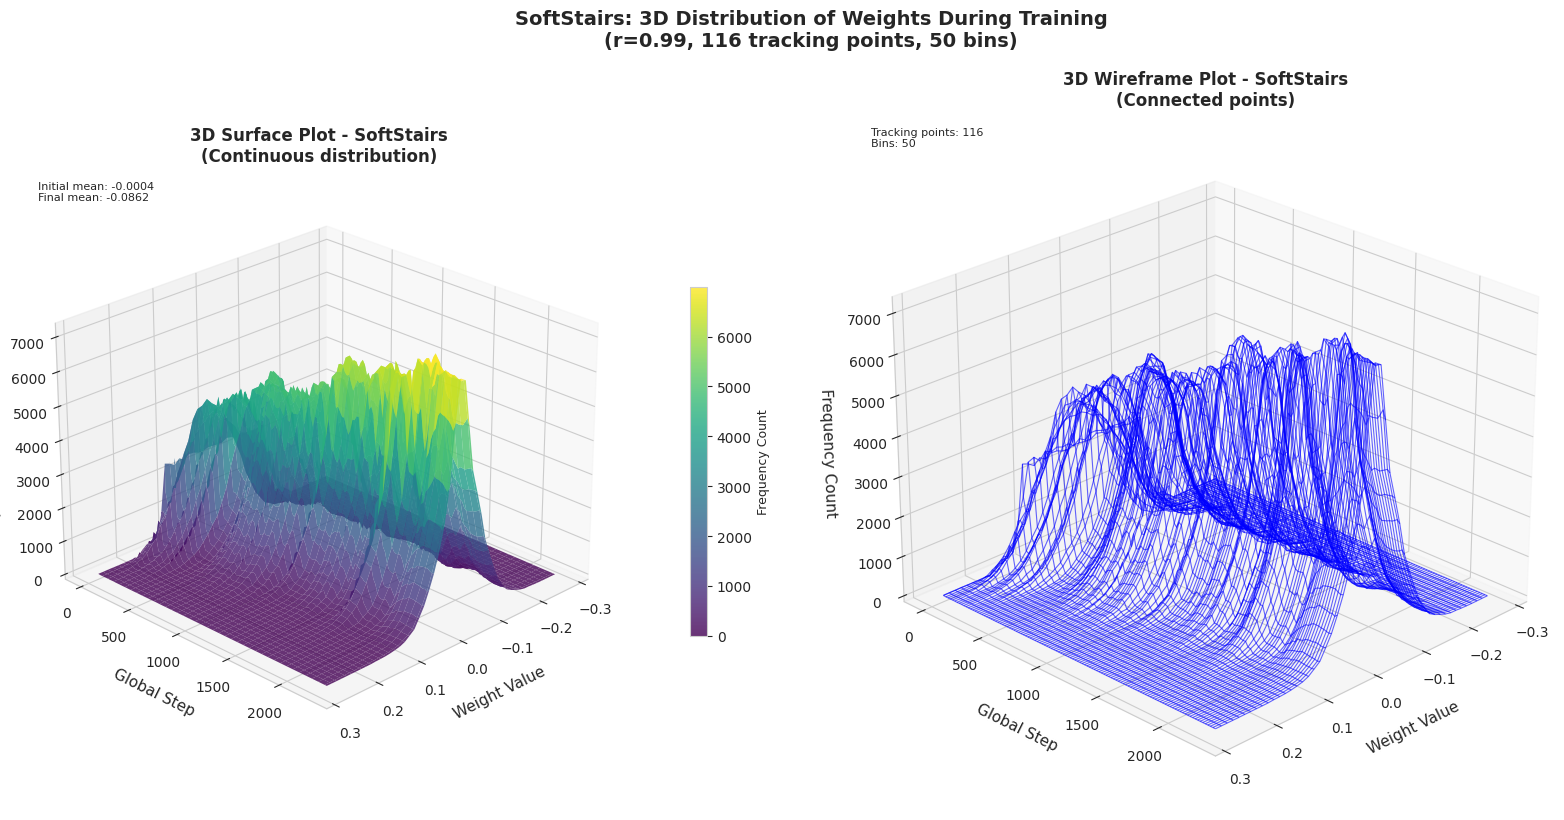

In [53]:
# ============================================================
# 10. 3D график с соединенными точками (surface/wireframe)
# ============================================================

def plot_3d_weight_distribution_with_lines(tracking_data, save_filename="softstairs_3d_distribution_surface.png"):
    """
    Строит 3D график распределения весов с соединенными точками
    Использует surface plot для плавного отображения
    """
    print("\n" + "=" * 80)
    print("ПОСТРОЕНИЕ 3D ГРАФИКА С СОЕДИНЕННЫМИ ТОЧКАМИ")
    print("=" * 80)
    
    # Определяем, какие данные использовать
    if 'weights_before_quant' in tracking_data:
        weights_key = 'weights_before_quant'
        print("  Используем оригинальные веса (weights_before_quant)")
    elif 'weights_distribution' in tracking_data:
        weights_key = 'weights_distribution'
        print("  Используем weights_distribution")
    else:
        print("  Ошибка: нет данных о весах")
        return None
    
    print(f"  Данные по {len(tracking_data['global_step'])} точкам трекинга")
    print(f"  Диапазон шагов: {tracking_data['global_step'][0]} -> {tracking_data['global_step'][-1]}")
    
    # Подготовка данных для 3D графика
    n_bins = 50
    
    # Собираем все гистограммы
    all_histograms = []
    all_step_values = []
    all_bin_centers = None
    
    for idx, weights in enumerate(tracking_data[weights_key]):
        if len(weights) > 0:
            hist, bin_edges = np.histogram(weights, bins=n_bins, density=False)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            step_value = tracking_data['global_step'][idx]
            
            if all_bin_centers is None:
                all_bin_centers = bin_centers
            
            all_histograms.append(hist)
            all_step_values.append(step_value)
    
    if len(all_histograms) == 0:
        print("  Ошибка: нет гистограмм для построения")
        return None
    
    # Преобразуем в массивы для surface plot
    X = np.array(all_bin_centers)  # значения весов
    Y = np.array(all_step_values)  # шаги обучения
    Z = np.array(all_histograms).T  # частоты (транспонируем для правильной ориентации)
    
    # Создаем meshgrid для surface plot
    X_grid, Y_grid = np.meshgrid(X, Y)
    
    # Создаем фигуру с двумя подграфиками
    fig = plt.figure(figsize=(16, 8))
    
    # 1. Surface plot (с заливкой)
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X_grid, Y_grid, Z.T, cmap='viridis', alpha=0.8, 
                            linewidth=0, antialiased=True)
    
    ax1.set_xlabel('Weight Value', fontsize=11, labelpad=8)
    ax1.set_ylabel('Global Step', fontsize=11, labelpad=8)
    ax1.set_zlabel('Frequency Count', fontsize=11, labelpad=8)
    ax1.set_title(f'3D Surface Plot - SoftStairs\n(Continuous distribution)', fontsize=12, fontweight='bold')
    
    cbar1 = fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=20, pad=0.1)
    cbar1.set_label('Frequency Count', fontsize=9)
    
    ax1.view_init(elev=25, azim=45)
    ax1.grid(True, alpha=0.3)
    
    # Добавляем статистику на surface plot
    first_weights = tracking_data[weights_key][0]
    last_weights = tracking_data[weights_key][-1]
    ax1.text2D(0.02, 0.98, f'Initial mean: {np.mean(first_weights):.4f}\nFinal mean: {np.mean(last_weights):.4f}', 
              transform=ax1.transAxes, fontsize=8, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # 2. Wireframe plot (только линии)
    ax2 = fig.add_subplot(122, projection='3d')
    wire = ax2.plot_wireframe(X_grid, Y_grid, Z.T, color='blue', alpha=0.6, 
                              linewidth=0.8, rstride=1, cstride=1)
    
    ax2.set_xlabel('Weight Value', fontsize=11, labelpad=8)
    ax2.set_ylabel('Global Step', fontsize=11, labelpad=8)
    ax2.set_zlabel('Frequency Count', fontsize=11, labelpad=8)
    ax2.set_title(f'3D Wireframe Plot - SoftStairs\n(Connected points)', fontsize=12, fontweight='bold')
    
    ax2.view_init(elev=25, azim=45)
    ax2.grid(True, alpha=0.3)
    
    # Добавляем статистику на wireframe plot
    ax2.text2D(0.02, 0.98, f'Tracking points: {len(all_step_values)}\nBins: {n_bins}', 
              transform=ax2.transAxes, fontsize=8, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # Добавляем общий заголовок
    r_value = tracking_data.get('r', 0.99)
    plt.suptitle(f'SoftStairs: 3D Distribution of Weights During Training\n(r={r_value}, {len(Y)} tracking points, {n_bins} bins)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\n3D график сохранен как: {save_filename}")
    plt.show()
    
    return fig

# Построение 3D графика с соединенными точками
fig_3d_surface = plot_3d_weight_distribution_with_lines(tracking_data, "softstairs_3d_distribution_surface.png")

In [14]:
# ============================================================
# Вычисление моментов разницы W - W_quant на всех весах
# ============================================================

def compute_moments_on_all_weights(tracking_data):
    """
    Вычисляет моменты для разницы W - W_quant, используя ВСЕ веса модели
    (уже объединенные в один массив через extract_all_weights)
    """
    print("\n" + "=" * 80)
    print("ВЫЧИСЛЕНИЕ МОМЕНТОВ НА ВСЕХ ВЕСАХ МОДЕЛИ")
    print("=" * 80)
    
    # Извлекаем данные
    steps = tracking_data['global_step']
    
    # Проверяем размерность
    print(f"\nКоличество точек трекинга: {len(tracking_data['weights_before_quant'])}")
    print(f"Размер массива весов в каждой точке: {len(tracking_data['weights_before_quant'][0]):,}")
    
    # Вычисляем разницу для каждого шага (уже на всех весах)
    mean_diffs = []
    var_diffs = []
    skew_diffs = []
    kurtosis_diffs = []
    
    for i in range(len(tracking_data['weights_before_quant'])):
        w = tracking_data['weights_before_quant'][i]
        w_quant = tracking_data['weights_after_quant'][i]
        
        if len(w) > 0 and len(w_quant) > 0:
            diff = w - w_quant
            
            # 1-й момент: среднее
            mean_val = np.mean(diff)
            mean_diffs.append(mean_val)
            
            # 2-й момент: дисперсия
            var_val = np.var(diff)
            var_diffs.append(var_val)
            
            # 3-й момент: асимметрия
            if len(diff) > 2:
                skew_val = stats.skew(diff)
            else:
                skew_val = 0
            skew_diffs.append(skew_val)
            
            # 4-й момент: эксцесс (для полноты)
            if len(diff) > 3:
                kurtosis_val = stats.kurtosis(diff)
            else:
                kurtosis_val = 0
            kurtosis_diffs.append(kurtosis_val)
    
    # Создаем DataFrame для удобства
    results_df = pd.DataFrame({
        'step': steps[:len(mean_diffs)],
        'mean_1st_moment': mean_diffs,
        'variance_2nd_moment': var_diffs,
        'skewness_3rd_moment': skew_diffs,
        'kurtosis_4th_moment': kurtosis_diffs
    })
    
    print(f"\nРезультаты (на всех {len(tracking_data['weights_before_quant'][0]):,} весах):")
    print(f"\nНачальные значения (step 0):")
    print(f"  Mean (1st):     {mean_diffs[0]:.10f}")
    print(f"  Variance (2nd): {var_diffs[0]:.10f}")
    print(f"  Skewness (3rd): {skew_diffs[0]:.10f}")
    print(f"  Kurtosis (4th): {kurtosis_diffs[0]:.10f}")
    
    print(f"\nКонечные значения (step {steps[len(mean_diffs)-1]}):")
    print(f"  Mean (1st):     {mean_diffs[-1]:.10f}")
    print(f"  Variance (2nd): {var_diffs[-1]:.10f}")
    print(f"  Skewness (3rd): {skew_diffs[-1]:.10f}")
    print(f"  Kurtosis (4th): {kurtosis_diffs[-1]:.10f}")
    
    print(f"\nИзменение за обучение:")
    print(f"  ΔMean:     {mean_diffs[-1] - mean_diffs[0]:.10f}")
    print(f"  ΔVariance: {var_diffs[-1] - var_diffs[0]:.10f}")
    print(f"  ΔSkewness: {skew_diffs[-1] - skew_diffs[0]:.10f}")
    
    return results_df

# Вычисляем моменты на всех весах
moments_df = compute_moments_on_all_weights(tracking_data)

# Сохраняем результаты
moments_df.to_csv('moments_w_minus_wquant_all_weights.csv', index=False)
print(f"\nРезультаты сохранены в: moments_w_minus_wquant_all_weights.csv")


ВЫЧИСЛЕНИЕ МОМЕНТОВ НА ВСЕХ ВЕСАХ МОДЕЛИ

Количество точек трекинга: 116
Размер массива весов в каждой точке: 57,984

Результаты (на всех 57,984 весах):

Начальные значения (step 0):
  Mean (1st):     0.0000000000
  Variance (2nd): 0.0000000000
  Skewness (3rd): -0.0065846656
  Kurtosis (4th): 46.0123649882

Конечные значения (step 2280):
  Mean (1st):     -0.0000000000
  Variance (2nd): 0.0000000000
  Skewness (3rd): -0.0252336105
  Kurtosis (4th): 13.8582544956

Изменение за обучение:
  ΔMean:     -0.0000000000
  ΔVariance: 0.0000000000
  ΔSkewness: -0.0186489450

Результаты сохранены в: moments_w_minus_wquant_all_weights.csv



ВИЗУАЛИЗАЦИЯ МОМЕНТОВ (с учетом масштаба выборки)

График сохранен как: moments_scale_aware.png


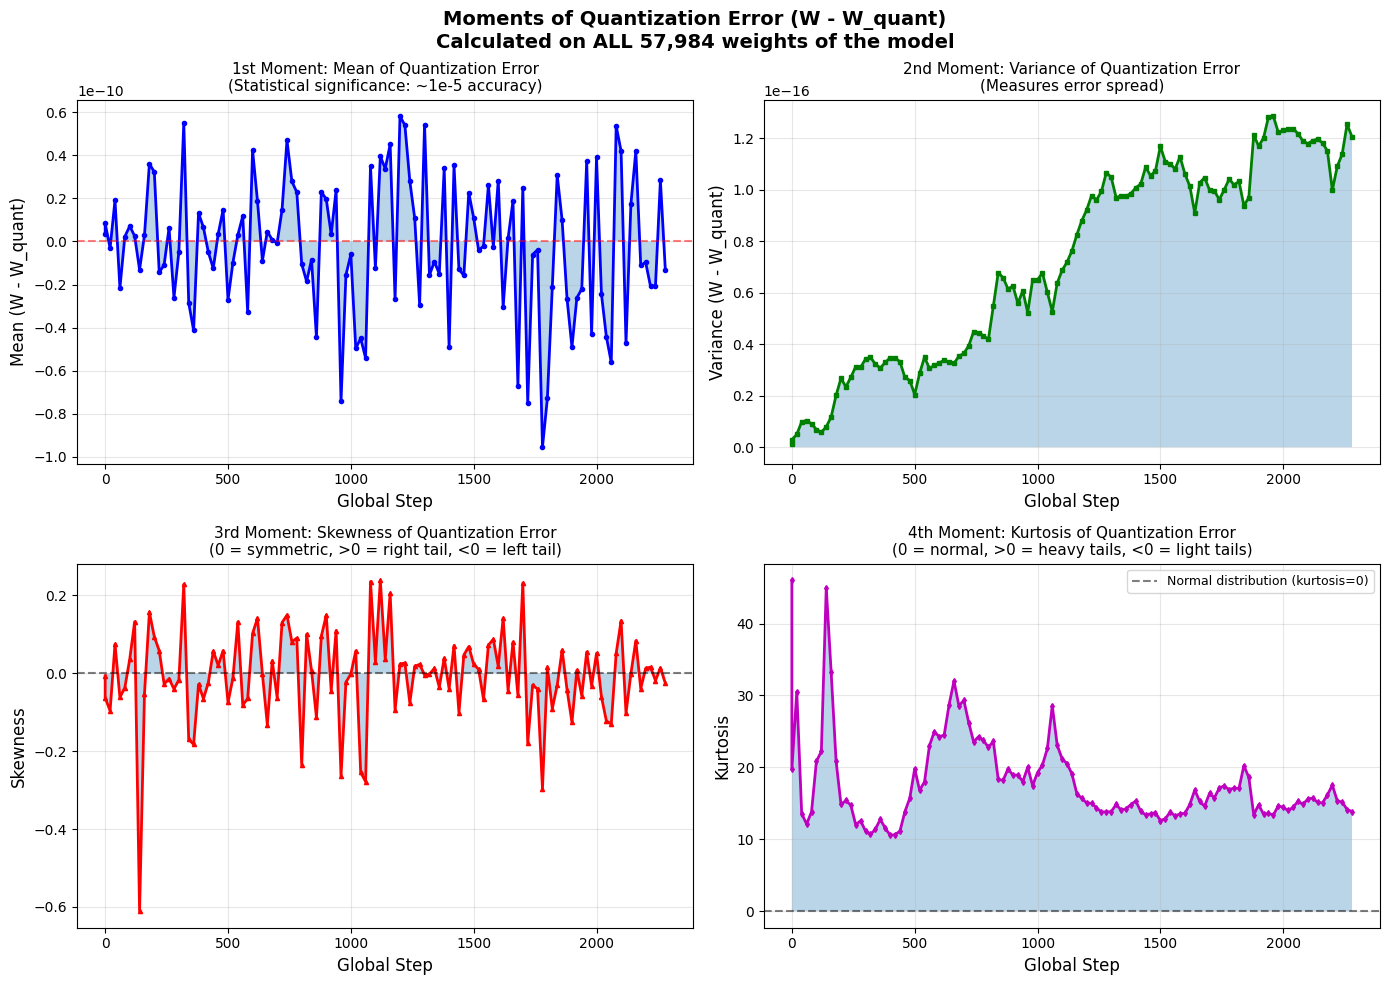

In [15]:
# ============================================================
# Визуализация моментов с учетом масштаба
# ============================================================

def plot_moments_with_scale_awareness(moments_df, save_filename="moments_scale_aware.png"):
    """
    Визуализирует моменты с информацией о масштабе выборки
    """
    print("\n" + "=" * 80)
    print("ВИЗУАЛИЗАЦИЯ МОМЕНТОВ (с учетом масштаба выборки)")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Среднее (1-й момент)
    ax1 = axes[0, 0]
    ax1.plot(moments_df['step'], moments_df['mean_1st_moment'], 'b-', linewidth=2, marker='o', markersize=3)
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax1.fill_between(moments_df['step'], moments_df['mean_1st_moment'], alpha=0.3)
    ax1.set_xlabel('Global Step', fontsize=12)
    ax1.set_ylabel('Mean (W - W_quant)', fontsize=12)
    ax1.set_title('1st Moment: Mean of Quantization Error\n(Statistical significance: ~1e-5 accuracy)', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. Дисперсия (2-й момент)
    ax2 = axes[0, 1]
    ax2.plot(moments_df['step'], moments_df['variance_2nd_moment'], 'g-', linewidth=2, marker='s', markersize=3)
    ax2.fill_between(moments_df['step'], moments_df['variance_2nd_moment'], alpha=0.3)
    ax2.set_xlabel('Global Step', fontsize=12)
    ax2.set_ylabel('Variance (W - W_quant)', fontsize=12)
    ax2.set_title('2nd Moment: Variance of Quantization Error\n(Measures error spread)', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Асимметрия (3-й момент)
    ax3 = axes[1, 0]
    ax3.plot(moments_df['step'], moments_df['skewness_3rd_moment'], 'r-', linewidth=2, marker='^', markersize=3)
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax3.fill_between(moments_df['step'], moments_df['skewness_3rd_moment'], alpha=0.3)
    ax3.set_xlabel('Global Step', fontsize=12)
    ax3.set_ylabel('Skewness', fontsize=12)
    ax3.set_title('3rd Moment: Skewness of Quantization Error\n(0 = symmetric, >0 = right tail, <0 = left tail)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # 4. Эксцесс (4-й момент)
    ax4 = axes[1, 1]
    ax4.plot(moments_df['step'], moments_df['kurtosis_4th_moment'], 'm-', linewidth=2, marker='d', markersize=3)
    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Normal distribution (kurtosis=0)')
    ax4.fill_between(moments_df['step'], moments_df['kurtosis_4th_moment'], alpha=0.3)
    ax4.set_xlabel('Global Step', fontsize=12)
    ax4.set_ylabel('Kurtosis', fontsize=12)
    ax4.set_title('4th Moment: Kurtosis of Quantization Error\n(0 = normal, >0 = heavy tails, <0 = light tails)', fontsize=11)
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)
    
    # Добавляем информацию о масштабе
    n_weights = len(tracking_data['weights_before_quant'][0])
    plt.suptitle(f'Moments of Quantization Error (W - W_quant)\nCalculated on ALL {n_weights:,} weights of the model', 
                fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"\nГрафик сохранен как: {save_filename}")
    plt.show()
    
    return fig

# Строим графики
if 'moments_df' in dir():
    fig_moments = plot_moments_with_scale_awareness(moments_df, "moments_scale_aware.png")

SoftStairs: функция и её производная


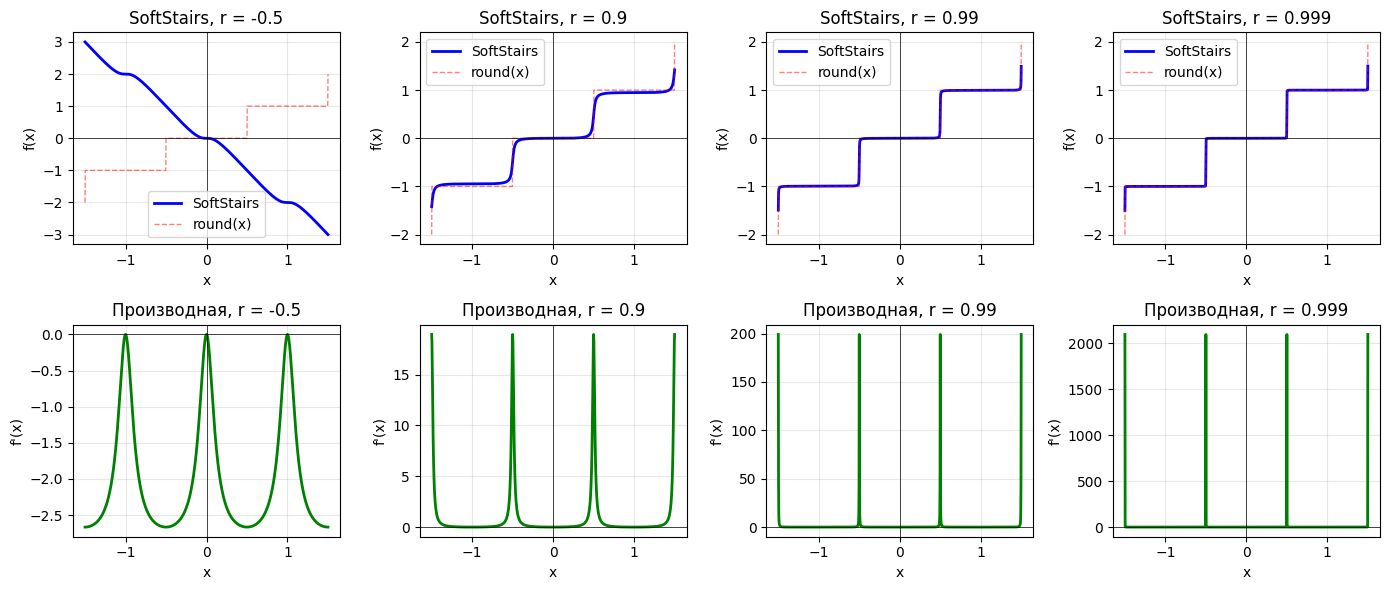

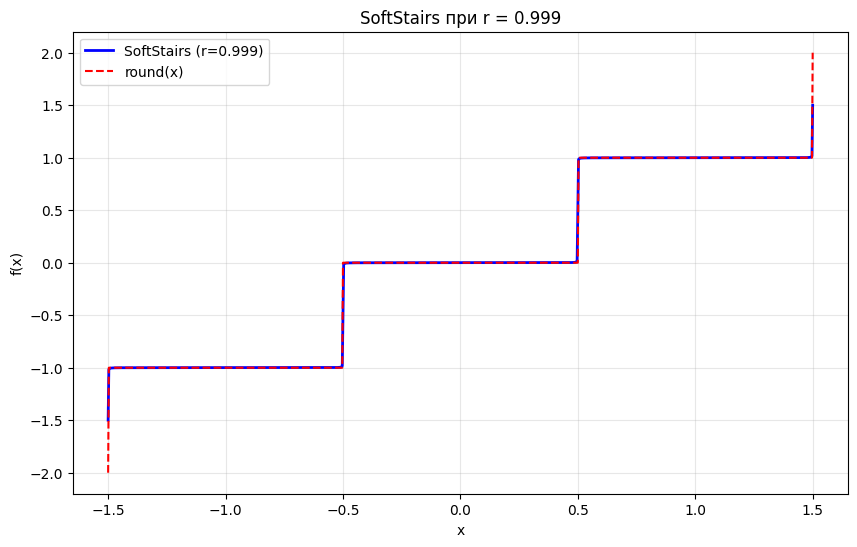

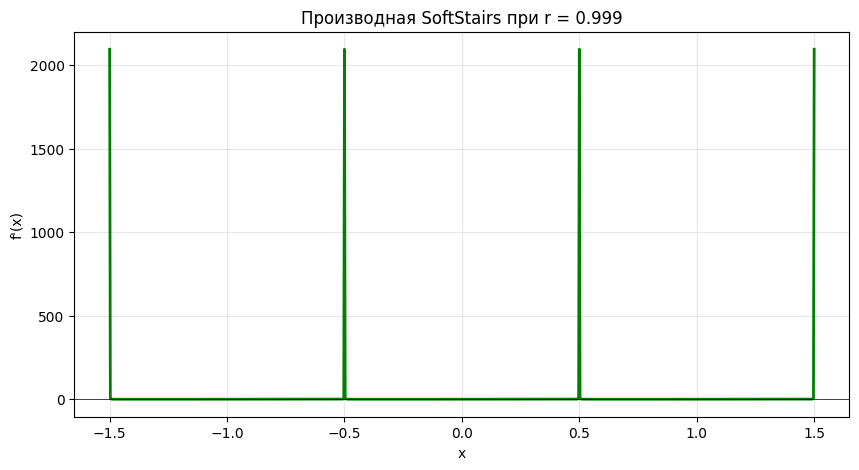

In [5]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

def soft_stairs_modified(x, r=0.999):
    original = x + (1.0 / math.pi) * torch.atan2(
        -r * torch.sin(2.0 * math.pi * x),
        1.0 + r * torch.cos(2.0 * math.pi * x)
    )
    correction = ((1 - r) / (r + 1)) * x
    return original - correction

def soft_stairs_modified_derivative(x, r=0.999):
    return (1.0 - r*r) / (1.0 + 2.0*r*torch.cos(2.0*math.pi*x) + r*r) - (1 - r) / (r + 1)

# ========== ГРАФИКИ ДЛЯ РАЗНЫХ ЗНАЧЕНИЙ r ==========
print("="*60)
print("SoftStairs: функция и её производная")
print("="*60)

# Диапазон x
x = torch.linspace(-1.5, 1.5, 1000)

# Параметры r для визуализации
r_values = [-0.5, 0.9, 0.99, 0.999]

# Графики функции (верхний ряд) и производной (нижний ряд)
fig, axes = plt.subplots(2, len(r_values), figsize=(14, 6))

for idx, r in enumerate(r_values):
    with torch.no_grad():
        y = soft_stairs_modified(x, r)
        y_prime = soft_stairs_modified_derivative(x, r)
    
    # График функции
    axes[0, idx].plot(x.numpy(), y.numpy(), 'b-', linewidth=2)
    axes[0, idx].plot(x.numpy(), torch.round(x).numpy(), 'r--', linewidth=1, alpha=0.5, label='round(x)')
    axes[0, idx].axhline(y=0, color='black', linewidth=0.5)
    axes[0, idx].axvline(x=0, color='black', linewidth=0.5)
    axes[0, idx].set_title(f'SoftStairs, r = {r}')
    axes[0, idx].set_xlabel('x')
    axes[0, idx].set_ylabel('f(x)')
    axes[0, idx].legend(['SoftStairs', 'round(x)'])
    axes[0, idx].grid(True, alpha=0.3)
    
    # График производной
    axes[1, idx].plot(x.numpy(), y_prime.numpy(), 'g-', linewidth=2)
    axes[1, idx].axhline(y=0, color='black', linewidth=0.5)
    axes[1, idx].axvline(x=0, color='black', linewidth=0.5)
    axes[1, idx].set_title(f'Производная, r = {r}')
    axes[1, idx].set_xlabel('x')
    axes[1, idx].set_ylabel("f'(x)")
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== ОТДЕЛЬНЫЙ ГРАФИК ФУНКЦИИ (КРУПНО) ==========
plt.figure(figsize=(10, 6))

r = 0.999
x_plot = torch.linspace(-1.5, 1.5, 1000)
y_modified = soft_stairs_modified(x_plot, r)
y_round = torch.round(x_plot)

plt.plot(x_plot.numpy(), y_modified.numpy(), 'b-', linewidth=2, label=f'SoftStairs (r={r})')
plt.plot(x_plot.numpy(), y_round.numpy(), 'r--', linewidth=1.5, label='round(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'SoftStairs при r = {r}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ========== ОТДЕЛЬНЫЙ ГРАФИК ПРОИЗВОДНОЙ (КРУПНО) ==========
plt.figure(figsize=(10, 5))

r = 0.999
x_deriv = torch.linspace(-1.5, 1.5, 1000)
y_deriv = soft_stairs_modified_derivative(x_deriv, r)

plt.plot(x_deriv.numpy(), y_deriv.numpy(), 'g-', linewidth=2)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title(f'Производная SoftStairs при r = {r}')
plt.grid(True, alpha=0.3)
plt.show()


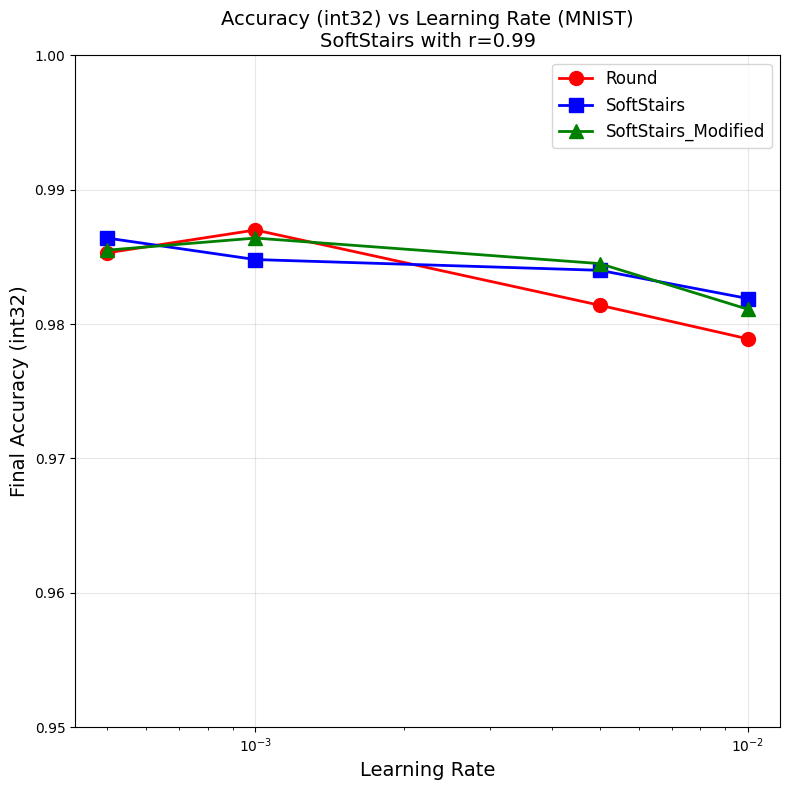


РЕЗУЛЬТАТЫ
 learning_rate            strategy  accuracy_int32
        0.0005               Round          0.9853
        0.0005          SoftStairs          0.9864
        0.0005 SoftStairs_Modified          0.9855
        0.0010               Round          0.9870
        0.0010          SoftStairs          0.9848
        0.0010 SoftStairs_Modified          0.9864
        0.0050               Round          0.9814
        0.0050          SoftStairs          0.9840
        0.0050 SoftStairs_Modified          0.9845
        0.0100               Round          0.9789
        0.0100          SoftStairs          0.9819
        0.0100 SoftStairs_Modified          0.9811


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# ЗАГРУЗКА РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТА
# ============================================================

# Загружаем полную статистику
df = pd.read_csv('full_statistics_MNIST.csv')

# Группируем по learning rate и стратегии, берём последнее значение accuracy_int32
final_acc_int32 = df.groupby(['learning_rate', 'strategy'])['accuracy_int32'].last().reset_index()

# Сортируем по learning rate
learning_rates = sorted(final_acc_int32['learning_rate'].unique())
strategies = ['Round', 'SoftStairs', 'SoftStairs_Modified']
colors = {'Round': 'red', 'SoftStairs': 'blue', 'SoftStairs_Modified': 'green'}
markers = {'Round': 'o', 'SoftStairs': 's', 'SoftStairs_Modified': '^'}

# ============================================================
# ПОСТРОЕНИЕ ГРАФИКА ACCURACY (INT32) VS LEARNING RATE
# ============================================================

plt.figure(figsize=(8, 8))

for strategy in strategies:
    data = final_acc_int32[final_acc_int32['strategy'] == strategy]
    if len(data) > 0:
        # Сортируем по learning rate для корректного отображения линии
        data_sorted = data.sort_values('learning_rate')
        plt.plot(data_sorted['learning_rate'], 
                data_sorted['accuracy_int32'], 
                marker=markers[strategy],
                color=colors[strategy],
                linewidth=2,
                markersize=10,
                label=strategy)

plt.xscale('log')
plt.xlabel('Learning Rate', fontsize=14)
plt.ylabel('Final Accuracy (int32)', fontsize=14)
plt.title(f'Accuracy (int32) vs Learning Rate (MNIST)\nSoftStairs with r=0.99', fontsize=14)
plt.ylim([0.95, 1.0])  # Ограничение по оси Y
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Добавляем аннотации значений
# for strategy in strategies:
#     data = final_acc_int32[final_acc_int32['strategy'] == strategy]
#     for _, row in data.iterrows():
#         plt.annotate(f'{row["accuracy_int32"]:.4f}', 
#                     xy=(row['learning_rate'], row['accuracy_int32']), 
#                     xytext=(5, 5 if row['accuracy_int32'] < 0.98 else -15), 
#                     textcoords='offset points',
#                     fontsize=9,
#                     alpha=0.8,
#                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('accuracy_int32_vs_lr_MNIST.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ")
print("="*60)
print(final_acc_int32.sort_values(['learning_rate', 'strategy']).to_string(index=False))